In [1]:
import glob
import numpy as np
import pandas as pd
import tables as tb

import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from matplotlib import cm

cmap = plt.get_cmap('viridis').copy()
cmap.set_under(color='white') 
plot_cmap = cm.get_cmap('turbo_r')

def lineal(x, a, b):
    return a*x + b

def in_range(x, rang):
    return (x > rang[0]) & (x < rang[1])

In [2]:
run_numbers = [15589, 15590, 15591, 15592, 15593, 15594, 15596, 15597] #, 15604, 15605, 15607]
run_times = {}

run_folder = 'HE_runs'
run_summary_name = 'run_cut_{}.h5'
wf_selection_name = 'sel_wf_{}.h5'

path = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/{run_folder}/{run_number}/'


In [75]:
# data_path = '/mnt/netapp1/Store_next_data/NEXT100/data/{run_number}'.format(run_number = run_number) + '*/*/*/*/*/*/*/*/'
# files = sorted(glob.glob(data_path + '*'), key=lambda x: (x.split('/')[-2], int(x.split('/')[-1].split('_')[2])))

In [76]:
from scipy.optimize import curve_fit
from scipy.integrate import quad

def gauss(x, a, mu, sigma):
    return a * np.exp(-((x - mu) / sigma) ** 2 / 2)

def expon(x, m, c):
    return m *np.exp(-x/c)

def peak_fit(x, a, mu, sigma, m, c):
    return gauss(x, a, mu, sigma) + expon(x, m, c)

def fit_and_plot_peaks_resolution(data, fun, nbins, plotrange, fitrange, initial_params, bounds, title, density = True, plot = False):
    y, x = np.histogram(data, nbins, range = plotrange, density = density)

    total_counts = len(data)
    bin_width = x[1] - x[0]

    if density:
        yerr = np.sqrt(y) / (bin_width * total_counts)
    else:
        yerr = np.sqrt(y)
    
    # Prevent zero errors
    yerr[yerr == 0] = np.min(yerr[yerr > 0]) if np.any(yerr > 0) else 1.0
    
    # from the xbins we select the range to plot, otherwise things don't match
    fit_mask = (x > fitrange[0]) & (x < fitrange[1])
    fit_x, fit_y, fit_yerr = x[fit_mask], y[fit_mask[:-1]], yerr[fit_mask[:-1]]
    params, cov = curve_fit(fun, fit_x, fit_y, p0=initial_params, sigma=fit_yerr, bounds = bounds, maxfev = 2000, absolute_sigma = True)
    err = np.sqrt(np.diag(cov))
    a, mu, sigma, m, c = params[0], params[1], params[2], params[3], params[4]
    yfit = fun(fit_x, a, mu, sigma, m, c)

    R = 2 * np.sqrt(2 * np.log(2)) * sigma * 100 / mu
    sR = R * np.sqrt((err[2] / sigma) **2 + (err[1]/mu)**2)

    if plot:
        legend_string = r'$\mu={:.3f} \pm {:.3e}$'.format(mu, err[1]) + '\n' + \
                        r'$\sigma={:.3f} \pm {:.3e}$'.format(sigma, err[2]) + '\n' + \
                        r'R(%) = ${:.3f} \pm {:.3e}$'.format(R, sR)
        plt.hist(data, nbins, range = plotrange, histtype='step', density = density)
        plt.errorbar(0.5 * (x[:-1] + x[1:]), y, yerr=yerr, fmt = ' ', c='tab:blue', alpha = 0.5)
        plt.plot(fit_x, yfit, 'r-', label = legend_string)
        plt.legend()
        plt.xlabel('E (MeV)')
        if density:
            plt.ylabel('Probability density (1 / MeV)')
        else:
            plt.ylabel('Events')
        plt.title(title)
        plt.grid()
        plt.show()
    return [params, err], [R, sR]

def fit_whole_peaks(df, var, model, range, nbins, initial_params = None, bounds = ([0, 0, 0, -np.inf, -np.inf], [np.inf, np.inf, np.inf, np.inf, np.inf]), density = False, title = '', plot = False):
    data = df[in_range(df[var], range)][var]

    y, x = np.histogram(data, nbins)
    if initial_params is None:
        A0 = max(y) - min(y)
        mu0 = x[np.argmax(y)]

        half_max = np.max(y) / 2
        indices = np.where(y > half_max)[0]
        fwhm = x[indices[-1]] - x[indices[0]]

        sig0 = fwhm / (2 * np.sqrt(2 * np.log(2)))  # FWHM = 2.355 * sigma
        m0 = np.min(y)

        initial_params = [A0, mu0, sig0, m0, 1]

    par, res = fit_and_plot_peaks_resolution(data, 
                                            model,
                                            nbins, 
                                            range, 
                                            range, 
                                            initial_params, 
                                            bounds, 
                                            title, 
                                            density=density, 
                                            plot = plot)
    return par, res

In [77]:
dst_summ, reco_summ, eff_summ = pd.DataFrame([]), pd.DataFrame([]), pd.DataFrame([])
for run_n in run_numbers:
    save_path_summary = path.format(run_folder = run_folder, run_number = run_n) + run_summary_name.format(run_n)
    run_dst  = pd.read_hdf(save_path_summary, 'DST/Events')
    run_dst['run_n'] = str(run_n)
    run_reco = pd.read_hdf(save_path_summary, 'RECO/Events_summary')
    eff = pd.read_hdf(save_path_summary, 'RUN/eff')
    eff['run_n'] = run_n

    dst_summ = dst_summ.append(run_dst)
    reco_summ = reco_summ.append(run_reco)
    eff_summ = eff_summ.append(eff)


In [78]:
run_numbers_2 = [15604, 15605, 15607]

run_folder = 'HE_runs'
run_summary_name_2 = 'run_cut_n8_{}.h5'

path = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/{run_folder}/{run_number}/'

In [70]:
# for run_n in run_numbers_2:
#     save_path_summary = path.format(run_folder = run_folder, run_number = run_n) + run_summary_name_2.format(run_n)
#     run_dst  = pd.read_hdf(save_path_summary, 'DST/Events')
#     run_dst['run_n'] = str(run_n)
#     run_reco = pd.read_hdf(save_path_summary, 'RECO/Events_summary')
#     eff = pd.read_hdf(save_path_summary, 'RUN/eff')
#     eff['run_n'] = run_n

#     dst_summ = dst_summ.append(run_dst)
#     reco_summ = reco_summ.append(run_reco)
#     eff_summ = eff_summ.append(eff)

In [ ]:
run_numbers = run_numbers # + run_numbers_2

In [79]:
reco_summ = reco_summ.fillna({'Ec_drop_in': 0, 'Ec_drop_out':0})

In [80]:
reco_summ['total_energy_d'] = reco_summ['total_energy'] - reco_summ['Ec_drop_out']

In [81]:
nlines = len(run_numbers)

min_val, max_val = 0.1, 0.9         # Avoid very dark/light extremes

plot_colors = [plot_cmap(min_val + (max_val - min_val) * i / (nlines - 1)) for i in range(nlines)]

### Efficiences

Text(0, 0.5, 'Eff (%)')

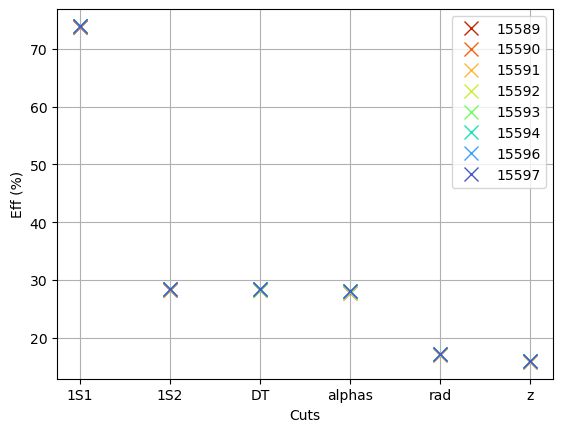

In [82]:
for run_n, c in zip(run_numbers, plot_colors):
    plt.plot(['1S1', '1S2', 'DT', 'alphas', 'rad', 'z'], (eff_summ[eff_summ.run_n == run_n][['1S1', '1S2', 'DT', 'alphas', 'rad', 'z']] / eff_summ[eff_summ.run_n == run_n][['total']].values).T * 100, 'x', color = c, markersize = 10, label = run_n)
plt.grid()
plt.legend()
plt.xlabel('Cuts')
plt.ylabel('Eff (%)')
# plt.yscale('log')

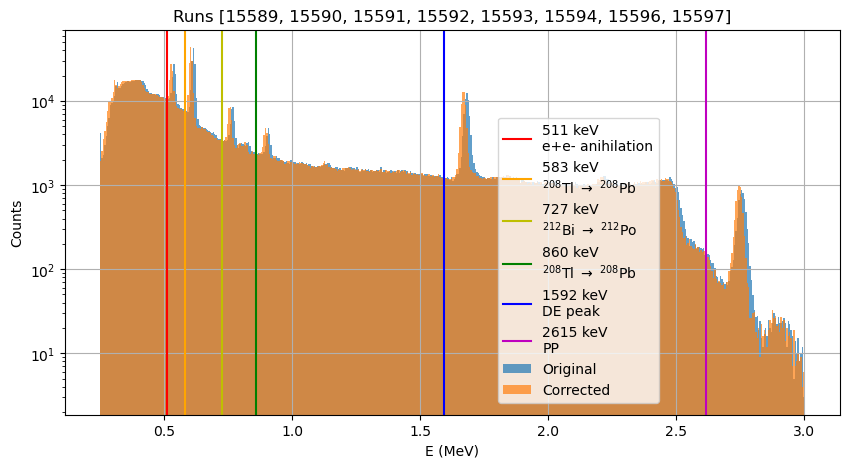

In [165]:
plt.figure(figsize=(10, 5))
plt.hist(reco_summ.total_energy, 500, (0.25, 3), alpha = 0.7, label = 'Original')
plt.hist(reco_summ.total_energy_d, 500, (0.25, 3), alpha = 0.7, label = 'Corrected')


plt.axvline(0.511, c = 'r', label = '511 keV\ne+e- anihilation')
plt.axvline(0.583, c = 'orange', label = '583 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(0.727, c = 'y', label = '727 keV\n' + r'$^{212}$Bi $\rightarrow$ $^{212}$Po')
plt.axvline(0.860, c = 'g', label = '860 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(1.592, c = 'b', label = '1592 keV\nDE peak')
plt.axvline(2.615, c = 'm', label = '2615 keV\nPP')
plt.grid()
plt.yscale('log')
plt.title('Runs {}'.format(run_numbers))
plt.xlabel('E (MeV)')
plt.ylabel('Counts')
plt.legend(loc = 'upper left', bbox_to_anchor = (0.55, 0.79))

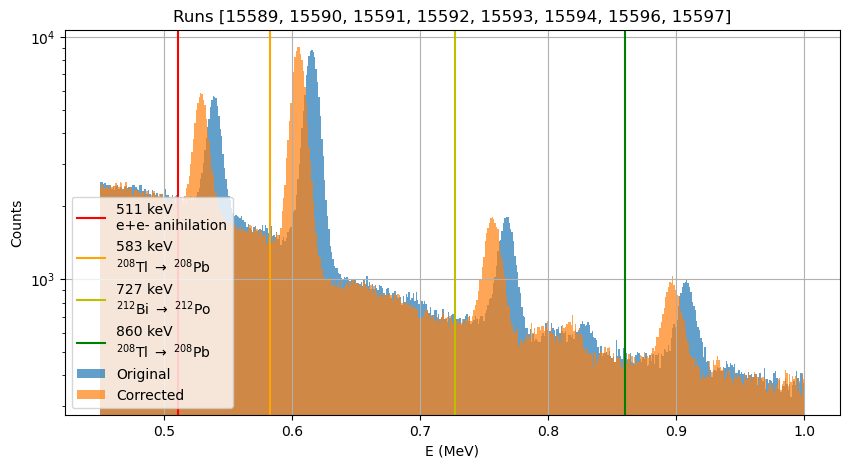

In [166]:
plt.figure(figsize=(10, 5))
plt.hist(reco_summ.total_energy, 500, (0.45, 1), alpha = 0.7, label = 'Original')
plt.hist(reco_summ.total_energy_d, 500, (0.45, 1), alpha = 0.7, label = 'Corrected')

plt.grid()
plt.yscale('log')
plt.axvline(0.511, c = 'r', label = '511 keV\ne+e- anihilation')
plt.axvline(0.583, c = 'orange', label = '583 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(0.727, c = 'y', label = '727 keV\n' + r'$^{212}$Bi $\rightarrow$ $^{212}$Po')
plt.axvline(0.860, c = 'g', label = '860 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.title('Runs {}'.format(run_numbers))
plt.xlabel('E (MeV)')
plt.ylabel('Counts')
plt.legend(loc = 'lower left')

### Energy scale

In [85]:
def get_peak_centers(run_numbers, reco_summ, variable, peak_ranges, npeaks = 4, plot = True):
    peak_nbins = [100, 100, 60, 40, 100, 25]
    peak_names  = ['e+e- anihilation (511 keV)', r'$^{208}$Tl $\rightarrow$ $^{208}$Pb (583 keV)', r'$^{212}$Bi $\rightarrow$ $^{212}$Po (727 keV)', r'$^{208}$Tl $\rightarrow$ $^{208}$Pb (860 keV)', '1592 keV\nDEP', '2615 keV\nPP']

    ranges = peak_ranges[:npeaks]
    nbins  = peak_nbins[:npeaks]
    names  = peak_names[:npeaks]
    
    meas_peaks = {}
    for run_n in run_numbers:
        run_reco = reco_summ[reco_summ.run_n == str(run_n)]
        meas_val, meas_err = [], []
        for rang, nbin, name in zip(ranges, nbins, names):
            par, res = fit_whole_peaks(run_reco, variable, peak_fit, rang, nbin, title = 'Run {} - '.format(run_n) + name, plot = plot)
            meas_val.append(par[0][1])
            meas_err.append(par[1][1])
        meas_peaks[run_n] = [meas_val, meas_err]
    return meas_peaks

In [86]:
peak_ranges = [(0.5, 0.58), (0.58, 0.65), (0.72, 0.81), (0.85, 0.95), (1.62, 1.75), (2.7, 2.8)]
peak_ranges_d = [(0.48, 0.56), (0.57, 0.64), (0.71, 0.80), (0.85, 0.95), (1.59, 1.72), (2.69, 2.79)]

In [87]:
meas_peaks = get_peak_centers(run_numbers, reco_summ, 'total_energy', peak_ranges, npeaks=4, plot = False)
meas_peaks_d = get_peak_centers(run_numbers, reco_summ, 'total_energy_d', peak_ranges_d, npeaks = 4, plot = False)
all_meas_peaks = get_peak_centers(run_numbers, reco_summ, 'total_energy', peak_ranges, npeaks = 6, plot = False)
all_meas_peaks_d = get_peak_centers(run_numbers, reco_summ, 'total_energy_d', peak_ranges_d, npeaks = 6, plot = False)

In [88]:
def plot_real_vs_meas_peaks(meas_peaks, run_numbers, plot_colors, npeak = 4):
    real_peaks = [0.511, 0.583, 0.727, 0.86, 1.592, 2.615]
    real_peaks = real_peaks[:npeak]
    for run_n, c in zip(run_numbers, plot_colors):
        if run_n not in meas_peaks.keys(): continue
        if len(meas_peaks[run_n][0]) == 0: continue
        m_ = np.array(meas_peaks[run_n][0])
        e_ = np.array(meas_peaks[run_n][1])
        r_ = np.array(real_peaks)
        plt.errorbar(r_, ((m_ - r_) / r_) * 100, yerr = e_ * 100, color = c, markersize = 10, label = run_n, marker = '.', capsize=2)
    plt.legend()
    plt.grid()
    plt.xlabel('Real peak energy (MeV)')
    plt.ylabel('(Measured - Real) / Real peak energy (%)')

Text(0.5, 1.0, '4 peaks')

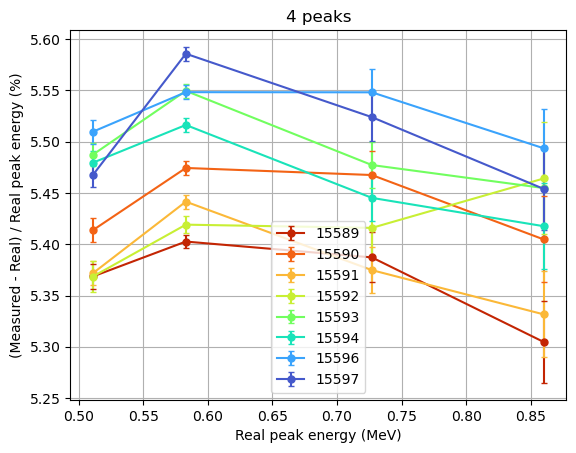

In [89]:
plot_real_vs_meas_peaks(meas_peaks, run_numbers, plot_colors, npeak = 4)
plt.title('4 peaks')

Text(0.5, 1.0, '4 peaks + removed outer hits E')

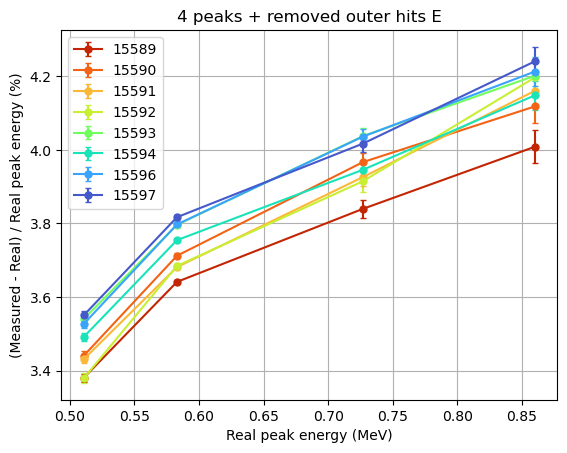

In [90]:
plot_real_vs_meas_peaks(meas_peaks_d, run_numbers, plot_colors, npeak = 4)
plt.title('4 peaks + removed outer hits E')

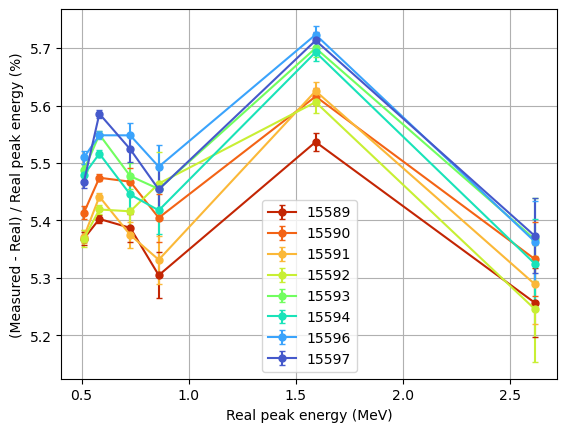

In [91]:
plot_real_vs_meas_peaks(all_meas_peaks, run_numbers, plot_colors, npeak = 6)
# plt.title('6 peaks')

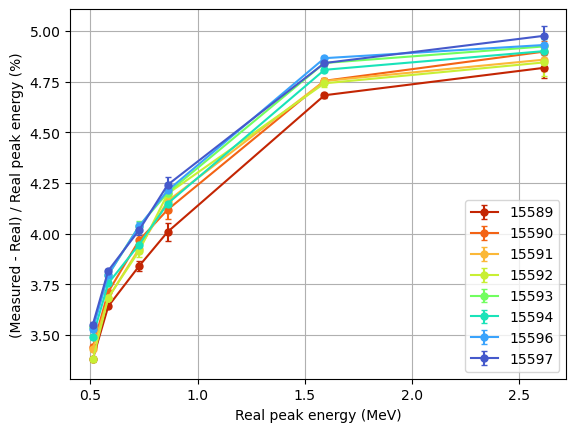

In [92]:
plot_real_vs_meas_peaks(all_meas_peaks_d, run_numbers, plot_colors, npeak = 6)
# plt.title('6 peaks + removed outer hits E')

In [93]:
def energy_scale_fit(meas_peaks, run_numbers, plot_colors, npeaks = 4):
    real_peaks = [0.511, 0.583, 0.727, 0.86, 1.592, 2.615]
    color_peak = ['r', 'orange', 'y', 'g', 'b', 'm']
    real_peaks = real_peaks[:npeaks]
    color_peak = color_peak[:npeaks]
    
    parameters = {}
    for run_n, c in zip(run_numbers, plot_colors):
        if run_n not in meas_peaks.keys(): continue
        if len(meas_peaks[run_n][0]) == 0: continue
        for m_, r_, c_ in zip(meas_peaks[run_n][0], real_peaks, color_peak):
            plt.plot(m_, r_, '.', color = c_)
        par, err  = curve_fit(lineal, meas_peaks[run_n][0], real_peaks, p0 = (1, 0))
        plt.plot(meas_peaks[run_n][0], lineal(np.array(meas_peaks[run_n][0]), *par), color = c, label = str(run_n) + '\n m = {:.2e}'.format(par[0]) + '\n n = {:.2e}'.format(par[1]))
        parameters[run_n] = par
    plt.legend(loc = 'center left', bbox_to_anchor = (1, 0.5))
    plt.grid()
    plt.xlabel('Measured peak energy (MeV)')
    plt.ylabel('Real peak energy (MeV)')
    return parameters

Text(0.5, 1.0, '4 peak fit')

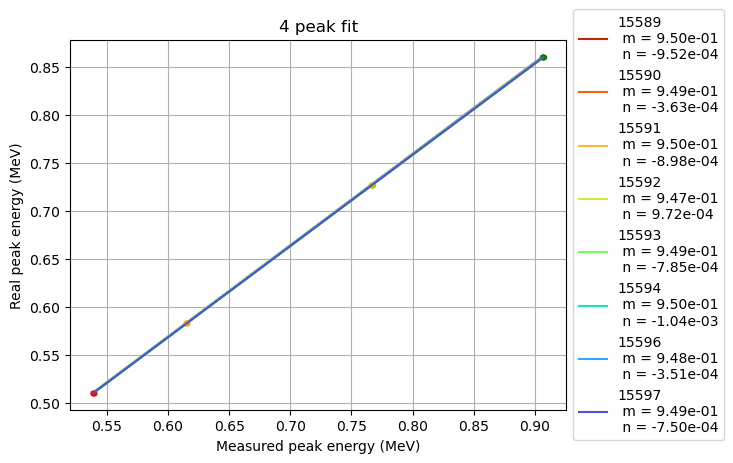

In [94]:
param = energy_scale_fit(meas_peaks, run_numbers, plot_colors, npeaks = 4)
plt.title('4 peak fit')

Text(0.5, 1.0, '4 peak fit + removed outer hits E')

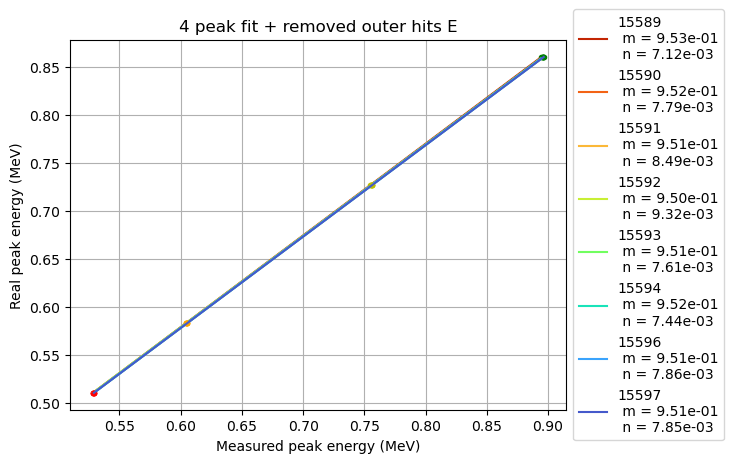

In [95]:
param_d = energy_scale_fit(meas_peaks_d, run_numbers, plot_colors, npeaks = 4)
plt.title('4 peak fit + removed outer hits E')

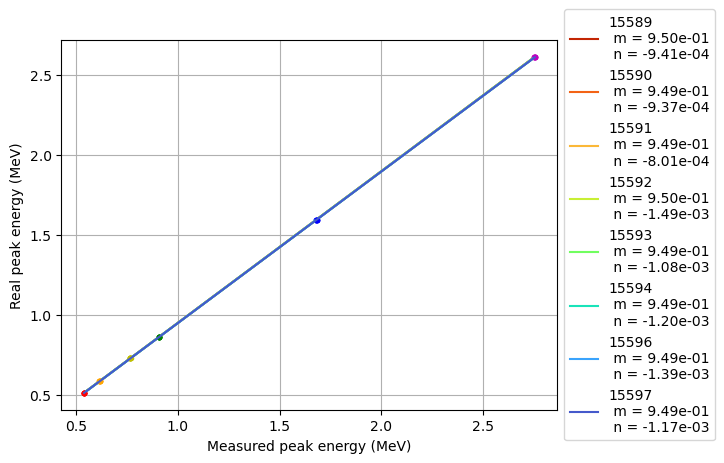

In [96]:
all_param = energy_scale_fit(all_meas_peaks, run_numbers, plot_colors, npeaks = 6)
# plt.title('6 peak fit')

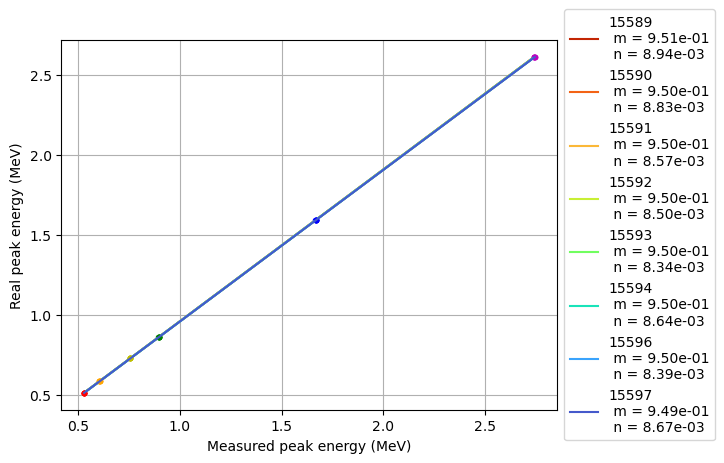

In [97]:
all_param_d = energy_scale_fit(all_meas_peaks_d, run_numbers, plot_colors, npeaks = 6)
# plt.title('6 peak fit + removed outer hits E')

In [98]:
reco_summ['E_shifted']   = reco_summ['total_energy'] * reco_summ['run_n'].map(lambda r: param[int(r)][0]) + reco_summ['run_n'].map(lambda r: param[int(r)][1])
reco_summ['E_shifted_d'] = reco_summ['total_energy_d'] * reco_summ['run_n'].map(lambda r: param_d[int(r)][0]) + reco_summ['run_n'].map(lambda r: param_d[int(r)][1])

reco_summ['E_shifted_all']   = reco_summ['total_energy'] * reco_summ['run_n'].map(lambda r: all_param[int(r)][0]) + reco_summ['run_n'].map(lambda r: all_param[int(r)][1])
reco_summ['E_shifted_all_d'] = reco_summ['total_energy_d'] * reco_summ['run_n'].map(lambda r: all_param_d[int(r)][0]) + reco_summ['run_n'].map(lambda r: all_param_d[int(r)][1])

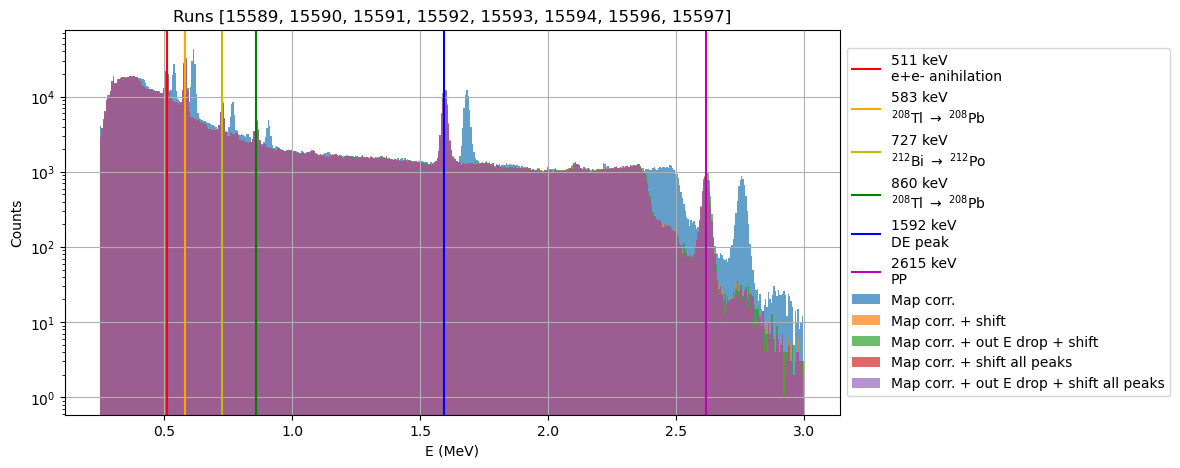

In [99]:
plt.figure(figsize=(10, 5))
plt.hist(reco_summ.total_energy, 500, (0.25, 3), alpha = 0.7, label = 'Map corr.')
plt.hist(reco_summ.E_shifted, 500, (0.25, 3), alpha = 0.7, label = 'Map corr. + shift')
plt.hist(reco_summ.E_shifted_d, 500, (0.25, 3), alpha = 0.7, label = 'Map corr. + out E drop + shift ')
plt.hist(reco_summ.E_shifted_all, 500, (0.25, 3), alpha = 0.7, label = 'Map corr. + shift all peaks')
plt.hist(reco_summ.E_shifted_all, 500, (0.25, 3), alpha = 0.7, label = 'Map corr. + out E drop + shift all peaks')

plt.grid()
plt.yscale('log')
plt.axvline(0.511, c = 'r', label = '511 keV\ne+e- anihilation')
plt.axvline(0.583, c = 'orange', label = '583 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(0.727, c = 'y', label = '727 keV\n' + r'$^{212}$Bi $\rightarrow$ $^{212}$Po')
plt.axvline(0.860, c = 'g', label = '860 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(1.592, c = 'b', label = '1592 keV\nDE peak')
plt.axvline(2.615, c = 'm', label = '2615 keV\nPP')
plt.title('Runs {}'.format(run_numbers))
plt.xlabel('E (MeV)')
plt.ylabel('Counts')
plt.legend(loc = 'center left', bbox_to_anchor = (1, 0.5))

### Peak deviation

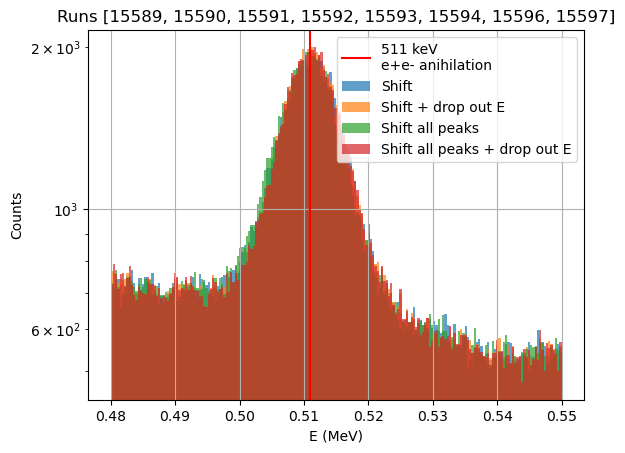

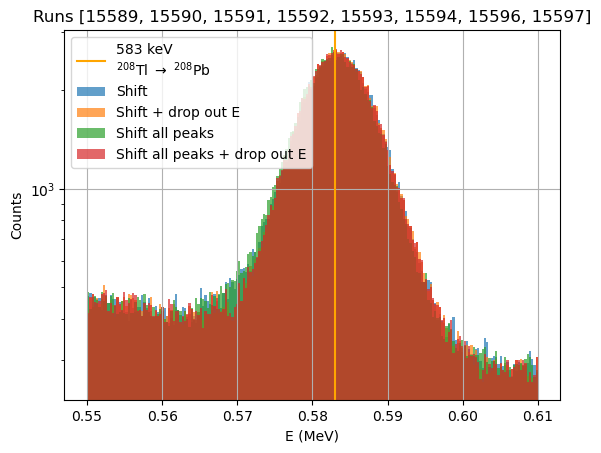

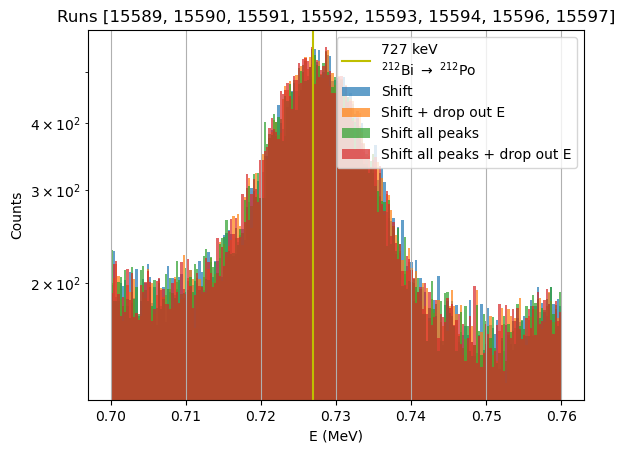

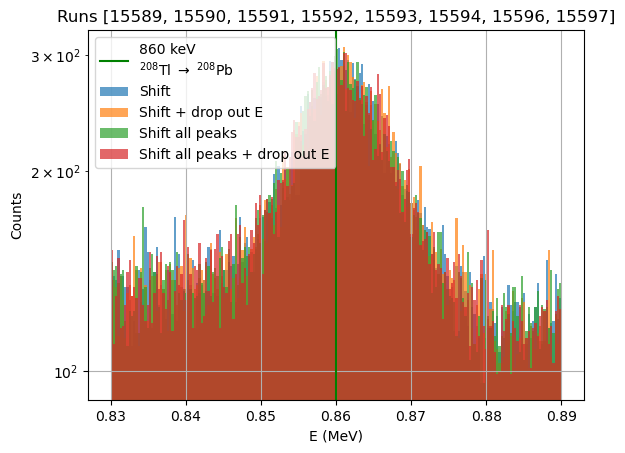

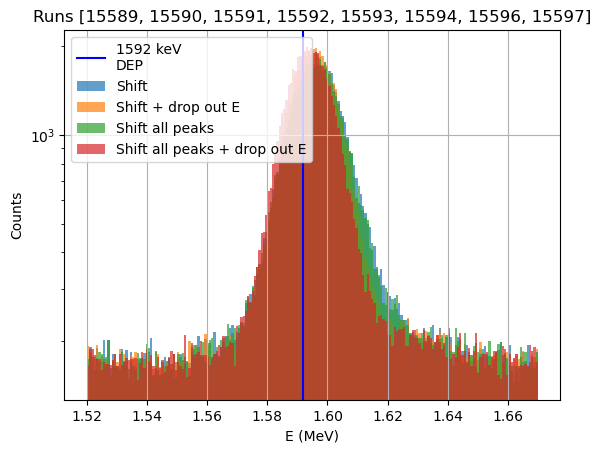

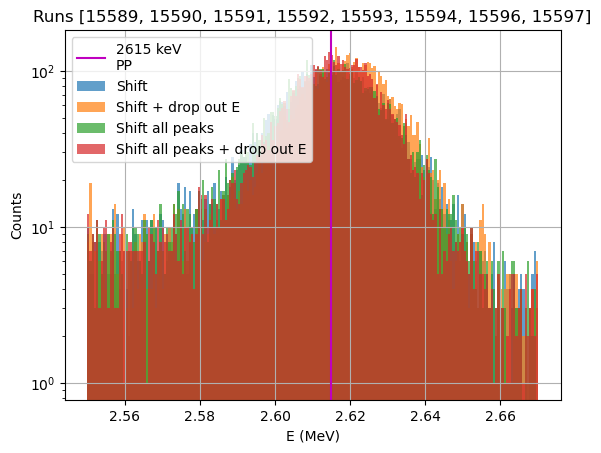

In [100]:
all_peak_ranges_shifted = [(0.48, 0.55), (0.55, 0.61), (0.7, 0.76), (0.83, 0.89), (1.52, 1.67), (2.55, 2.67)]
all_real_peaks = [0.511, 0.583, 0.727, 0.86, 1.592, 2.615]
all_peak_colors = ['r', 'orange', 'y', 'g', 'b', 'm']
all_peak_names  = ['511 keV\ne+e- anihilation', '583 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb', '727 keV\n' + r'$^{212}$Bi $\rightarrow$ $^{212}$Po', '860 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb', '1592 keV\nDEP', '2615 keV\nPP']


for rang, peak, lab, col in zip(all_peak_ranges_shifted, all_real_peaks, all_peak_names, all_peak_colors):
    plt.figure()
    plt.hist(reco_summ.E_shifted, 200, rang, alpha = 0.7, label = 'Shift')
    plt.hist(reco_summ.E_shifted_d, 200, rang, alpha = 0.7, label = 'Shift + drop out E')
    plt.hist(reco_summ.E_shifted_all, 200, rang, alpha = 0.7, label = 'Shift all peaks')
    plt.hist(reco_summ.E_shifted_all_d, 200, rang, alpha = 0.7, label = 'Shift all peaks + drop out E')
    plt.axvline(peak, c = col, label = lab)
    plt.grid()
    plt.yscale('log')
    plt.title('Runs {}'.format(run_numbers))
    plt.xlabel('E (MeV)')
    plt.ylabel('Counts')
    plt.legend()

4 cases:
* 4 peak fit
* 4 peak fit + dropped hits
* 6 peak fit
* 6 peak fit + dropped hits

In [101]:
peak_ranges_shift = [(0.48, 0.55), (0.55, 0.61), (0.7, 0.76), (0.83, 0.89), (1.52, 1.67), (2.55, 2.67)]

In [102]:
# I want to check always the 6 peaks, but with 4 and 6 peaks param correction
meas_peaks_shift = get_peak_centers(run_numbers, reco_summ, 'E_shifted', peak_ranges_shift, npeaks=6, plot = False)
meas_peaks_shift_d = get_peak_centers(run_numbers, reco_summ, 'E_shifted_d', peak_ranges_shift, npeaks=6, plot = False)
meas_peaks_shift_all = get_peak_centers(run_numbers, reco_summ, 'E_shifted_all', peak_ranges_shift, npeaks=6, plot = False)
meas_peaks_shift_all_d = get_peak_centers(run_numbers, reco_summ, 'E_shifted_all_d', peak_ranges_shift, npeaks=6, plot = False)


Text(0.5, 1.0, '4 peak fit')

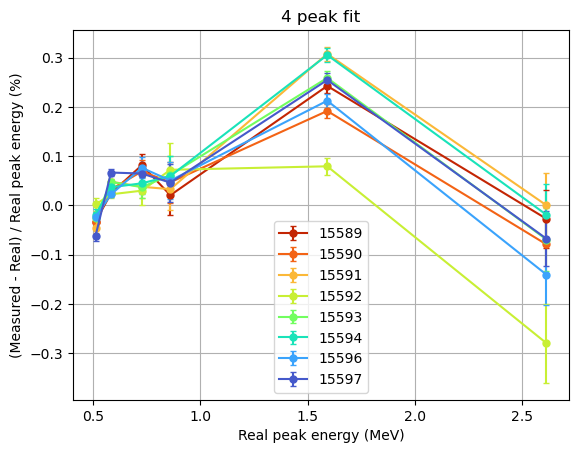

In [103]:
plot_real_vs_meas_peaks(meas_peaks_shift, run_numbers, plot_colors, npeak=6)
plt.title('4 peak fit')

Text(0.5, 1.0, '4 peak fit + drop out E')

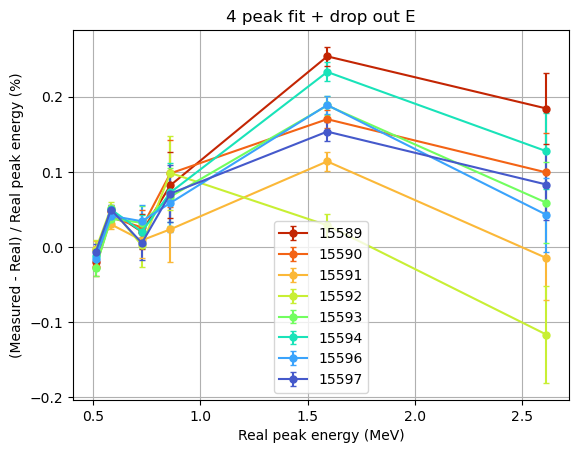

In [104]:
plot_real_vs_meas_peaks(meas_peaks_shift_d, run_numbers, plot_colors, npeak=6)
plt.title('4 peak fit + drop out E')

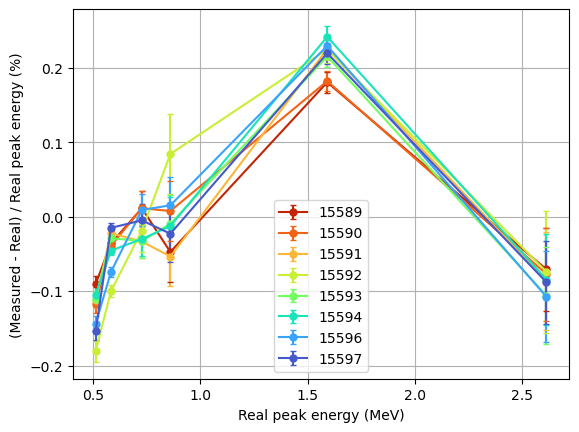

In [105]:
plot_real_vs_meas_peaks(meas_peaks_shift_all, run_numbers, plot_colors, npeak=6)
# plt.title('6 peak fit')

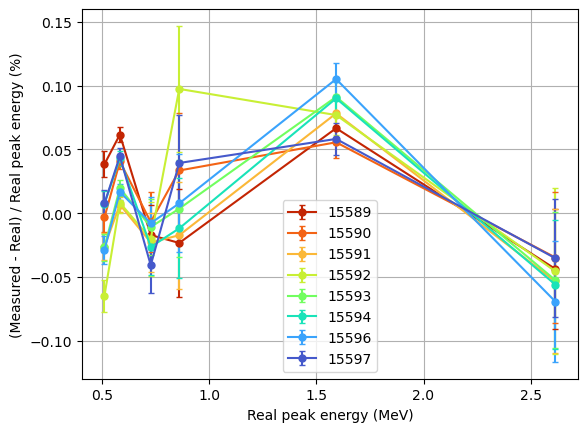

In [106]:
plot_real_vs_meas_peaks(meas_peaks_shift_all_d, run_numbers, plot_colors, npeak=6)
# plt.title('6 peak fit + drop out E')

### E resolution (with no corrections)

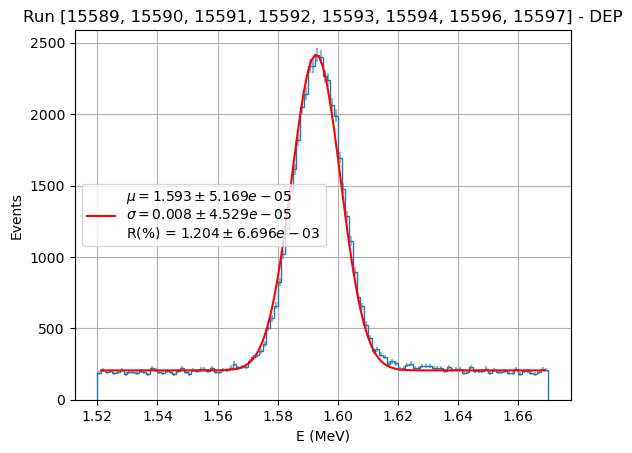

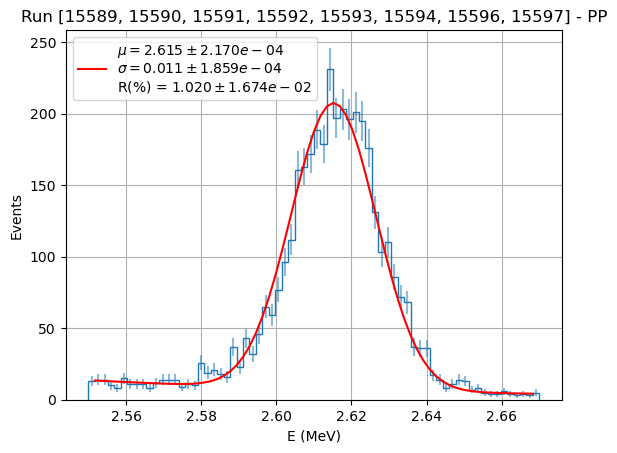

Energy resolution DEP: 1.204 ± 0.007 %
Energy resolution PP: 1.020 ± 0.017 %


In [107]:
_, r_dep = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], 'E_shifted_all_d', peak_fit, all_peak_ranges_shifted[-2], 120, title = 'Run {} - '.format(run_numbers) + 'DEP', plot = True)
plt.show()
_, r_pp = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], 'E_shifted_all_d', peak_fit, all_peak_ranges_shifted[-1], 70, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True)
plt.show()
print('Energy resolution DEP: {:.3f} ± {:.3f} %'.format(r_dep[0], r_dep[1]))
print('Energy resolution PP: {:.3f} ± {:.3f} %'.format(r_pp[0], r_pp[1]))

### Dependencies of E with variables

In [108]:
from invisible_cities.core.fit_functions import expo
from invisible_cities.core.fit_functions import profileX
from scipy.optimize                      import curve_fit

def quad(x, a, b, c):
    return a*x**2 + b*x + c


def plot_profile(df, xvar, yvar, fitfun = None, initial_values = None, std = False, fitbins = 20, plotbins = (50, 50), fitrange = (None, None), plotrange = (None, None), axlabel = ['', ''], units = ['mm', 'MeV'], title = '', cmap = 'viridis'):
    x, y, sy = profileX(df[xvar], df[yvar], std=std, nbins = fitbins, xrange = fitrange[0], yrange=fitrange[1])
    par = None
    if fitfun:
        par, err  = curve_fit(fitfun, x, y, sigma=sy, p0 = initial_values)
        label_lines = [f'$x_{{{i}}}$ = {p:.2e} ' + r'$\mathrm{' + units[1] + r'}/\mathrm{' + units[0] + r'}^{{' + f'{i}' + '}}$' for i, p in enumerate(par[::-1])]
        label = "\n".join(label_lines)

        plt.plot(x, fitfun(x, *par), 'r-', label = label)
    plt.errorbar(x = x, y = y, yerr = sy, fmt = 'r.')

    plt.hist2d(df[xvar], df[yvar], bins = plotbins, range = plotrange, cmap = cmap, vmin = 1e-3)
    plt.xlabel(axlabel[0] + ' ({})'.format(units[0]))
    plt.ylabel(axlabel[1] + ' ({})'.format(units[1]))
    plt.legend()
    plt.title(title)
    plt.show()
    if type(par) != None: 
        return par
    
def plot_hist2d(df, xvar, yvar, plotbins = (50, 50), plotrange = (None, None), axlabel = ['', ''], units = ['mm', 'MeV'], title = '', cmap = 'viridis'):
    plt.hist2d(df[xvar], df[yvar], bins = plotbins, range = plotrange, cmap = cmap, vmin = 1e-3)
    plt.xlabel(axlabel[0] + ' ({})'.format(units[0]))
    plt.ylabel(axlabel[1] + ' ({})'.format(units[1]))
    plt.title(title)
    plt.show()

In [109]:
reco_summ = reco_summ.merge(dst_summ[['event', 'run_n', 'S1e', 'S2e']], on = ['event', 'run_n'])

In [110]:
# plot_profile(reco_summ[in_range(reco_summ.E_shifted, (1.56, 1.63))], 'S1e', 'E_shifted', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), None), plotrange=((200, 400), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted_d, (1.56, 1.63))], 'S1e', 'E_shifted_d', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), None), plotrange=((200, 400), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP - D'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted_all, (1.56, 1.63))], 'S1e', 'E_shifted_all', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), None), plotrange=((200, 400), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP - 6p'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted_all_d, (1.56, 1.63))], 'S1e', 'E_shifted_all_d', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), None), plotrange=((200, 400), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP - 6pD'.format(run_numbers), cmap=cmap)


In [111]:
# plot_profile(reco_summ[in_range(reco_summ.E_shifted, (1.56, 1.63))], 'dX', 'E_shifted', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((110, 350), None), plotrange=((110, 350), None), axlabel = [r'$\Delta$X', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted, (1.56, 1.63))], 'Xmin', 'E_shifted', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=15, plotbins=(15, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Xmin', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'Xmax', 'E_shifted', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=15, plotbins=(15, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Xmax', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'X_bary', 'E_shifted', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=15, plotbins=(15, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'X_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)

# plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'dY', 'E_shifted', fitfun=lineal, initial_values=(1.67, 0), std = False, fitbins=15, plotbins=(15, 40), fitrange=((110, 350), None), plotrange=((110, 350), None), axlabel = [r'$\Delta$Y', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'Ymin', 'E_shifted', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=15, plotbins=(15, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Ymin', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'Ymax', 'E_shifted', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=15, plotbins=(15, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Ymax', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'Y_bary', 'E_shifted', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=15, plotbins=(15, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Y_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)

# plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'dZ', 'E_shifted', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=30, plotbins=(30, 30), fitrange=((40, 300), None), plotrange=((40, 300), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'Zmin', 'E_shifted', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=30, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Zmin', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'Zmax', 'E_shifted', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=30, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Zmax', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'Z_bary', 'E_shifted', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=30, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)

# plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'Rmax', 'E_shifted', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=30, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Rmax', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'num_hits', 'E_shifted', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=30, plotbins=(30, 30), fitrange=((800, 1600), None), plotrange=((800, 1600), None), axlabel = [r'# hits', 'E'], units= ['nhits', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)

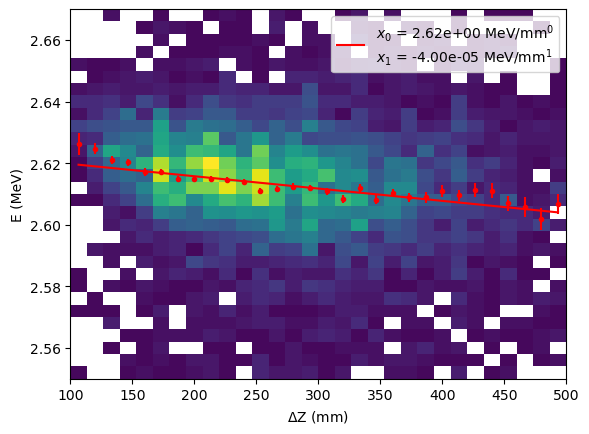

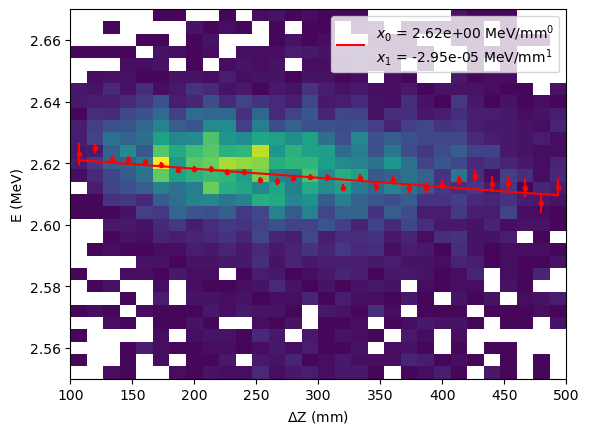

array([-2.94659996e-05,  2.62408034e+00])

In [112]:

# plot_profile(reco_summ[in_range(reco_summ.E_shifted, 2.52, 2.7)], 'dX', 'E_shifted', fitfun=lineal, initial_values=(1.67, 0), std = False, fitbins=15, plotbins=(15, 30), fitrange=((114, 600), None), plotrange=((140, 560), None), axlabel = [r'$\Delta$X', 'E'], title = 'Runs {} - PP'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted, 2.52, 2.7)], 'dY', 'E_shifted', fitfun=lineal, initial_values=(1.67, 0), std = False, fitbins=15, plotbins=(15, 30), fitrange=((114, 600), None), plotrange=((140, 560), None), axlabel = [r'$\Delta$Y', 'E'], cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ.E_shifted, (2.5, 2.75))], 'dZ', 'E_shifted', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=30, plotbins=(30, 30), fitrange=((100, 500), (2.55, 2.67)), plotrange=((100, 500), (2.55, 2.67)), axlabel = [r'$\Delta$Z', 'E'], cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ.E_shifted_d, (2.5, 2.75))], 'dZ', 'E_shifted_d', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=30, plotbins=(30, 30), fitrange=((100, 500), (2.55, 2.67)), plotrange=((100, 500), (2.55, 2.67)), axlabel = [r'$\Delta$Z', 'E'], cmap=cmap)


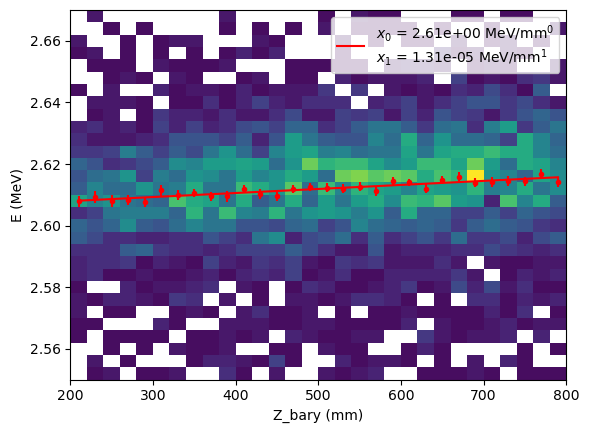

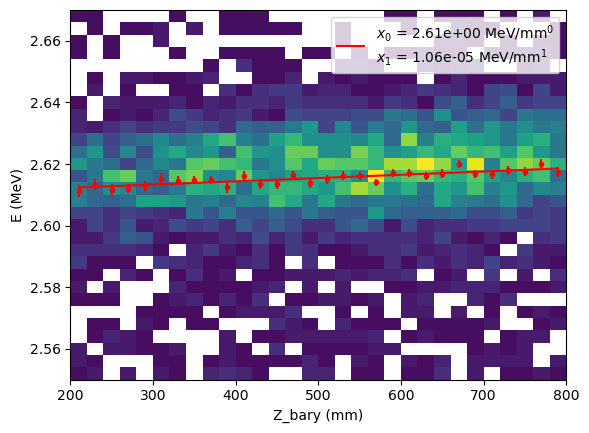

array([1.06172261e-05, 2.61012445e+00])

In [113]:
plot_profile(reco_summ[in_range(reco_summ.E_shifted, (2.5, 2.75))], 'Z_bary', 'E_shifted', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=30, plotbins=(30, 30), fitrange=((200, 800), (2.55, 2.67)), plotrange=((200, 800), (2.55, 2.67)), axlabel = ['Z_bary', 'E'], cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ.E_shifted_d, (2.5, 2.75))], 'Z_bary', 'E_shifted_d', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=30, plotbins=(30, 30), fitrange=((200, 800), (2.55, 2.67)), plotrange=((200, 800), (2.55, 2.67)), axlabel = ['Z_bary', 'E'], cmap=cmap)


### E resolution (no corrections + selected range)

In [114]:
ene_var_corr = 'E_shifted_all_d'

dep_range = (1.565, 1.62)
dep_nbins = 120
pp_range = (2.58, 2.65)
pp_nbins = 70

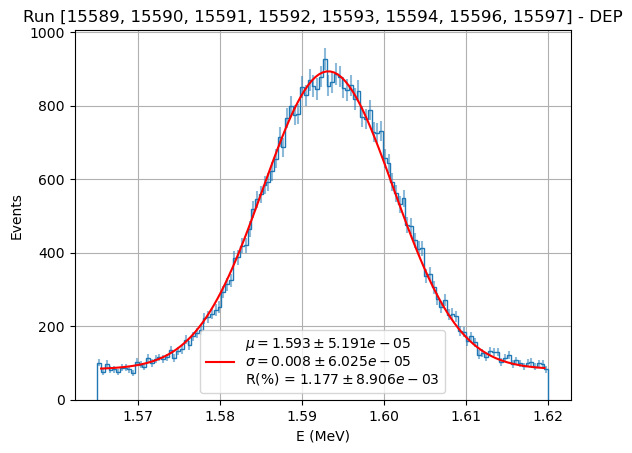

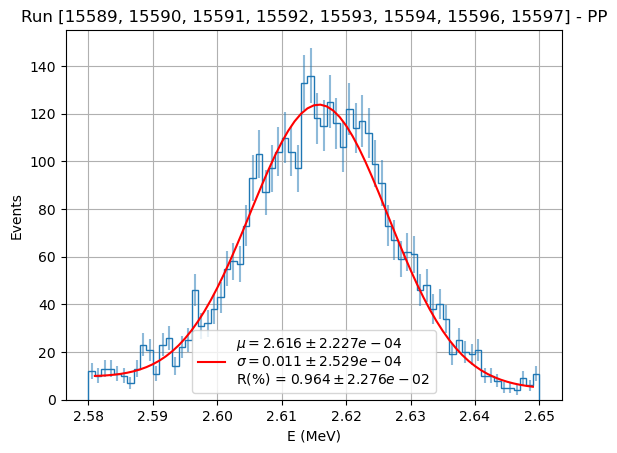

Energy resolution DEP: 1.177 ± 0.009 %
Energy resolution PP: 0.964 ± 0.023 %


In [115]:
_, r_dep = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, dep_range, dep_nbins, title = 'Run {} - '.format(run_numbers) + 'DEP', plot = True)
plt.show()
_, r_pp  = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, pp_range, pp_nbins, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True)
plt.show()
print('Energy resolution DEP: {:.3f} ± {:.3f} %'.format(r_dep[0], r_dep[1]))
print('Energy resolution PP: {:.3f} ± {:.3f} %'.format(r_pp[0], r_pp[1]))

# AL AÑADIR LOS RUNS 15605, 15607 EMPEORÓ LA RESOLUCION...... esto viene de bajar el corte en Q (de 7 a 5)--> para solucionarlo habría tb que cambiar el nhits en drop_isolated_clusters

### HACER UNA FUNCION Q RECURSIVAMENTE ME VAYA HACIENDO UN RANGO DE SELECCION DE DATOS HASTA QUE NO HAYA VARIACIÓN EN LA MEDIA O ALGO ASÍ???

In [116]:
# plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'dZ', 'E_shifted', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 20), fitrange=((60, 250), None), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted_d, 1.56, 1.63)], 'dZ', 'E_shifted_d', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 20), fitrange=((60, 250), None), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP - dropped'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted_all, 1.56, 1.63)], 'dZ', 'E_shifted_all', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 20), fitrange=((60, 250), None), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP - 6peaks'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted_all_d, 1.56, 1.63)], 'dZ', 'E_shifted_all_d', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 20), fitrange=((60, 250), None), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP - 6peaks+dropped'.format(run_numbers), cmap=cmap)


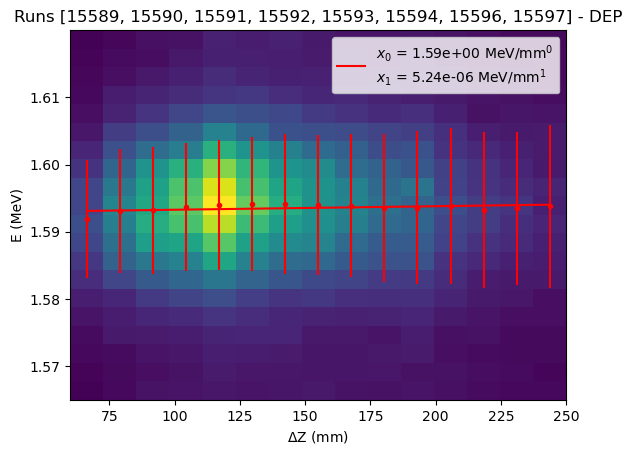

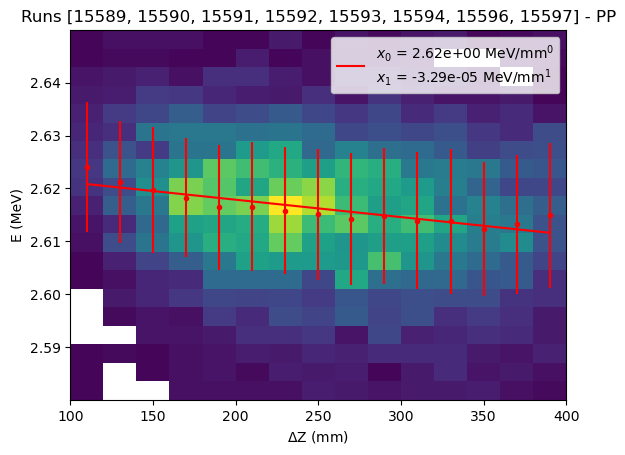

array([-3.29225397e-05,  2.62444603e+00])

In [117]:
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], dep_range)], 'dZ', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 20), fitrange=((60, 250), None), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr],  pp_range)], 'dZ', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 20), fitrange=((100, 400), None), plotrange=((100, 400), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)


##### A simple vista podemos apreciar que el PP si que tiene dependencia, pero el DEP no...

In [118]:
# plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'Z_bary', 'E_shifted', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted_d, 1.56, 1.63)], 'Z_bary', 'E_shifted_d', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - DEP - drop'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted_all, 1.56, 1.63)], 'Z_bary', 'E_shifted_all', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - DEP - 6peaks'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted_all_d, 1.56, 1.63)], 'Z_bary', 'E_shifted_all_d', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - DEP - 6peaks+dropped'.format(run_numbers), cmap=cmap)


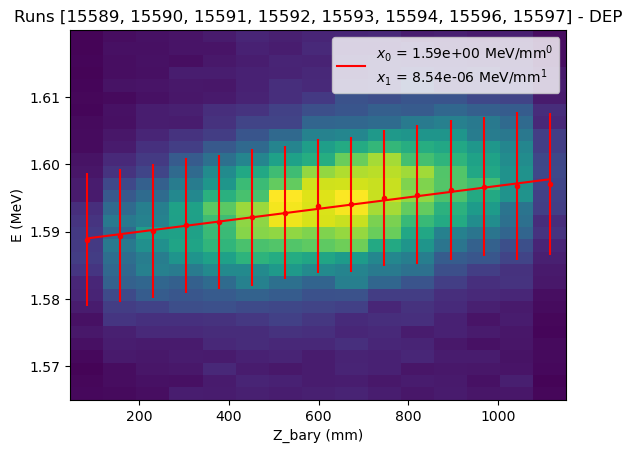

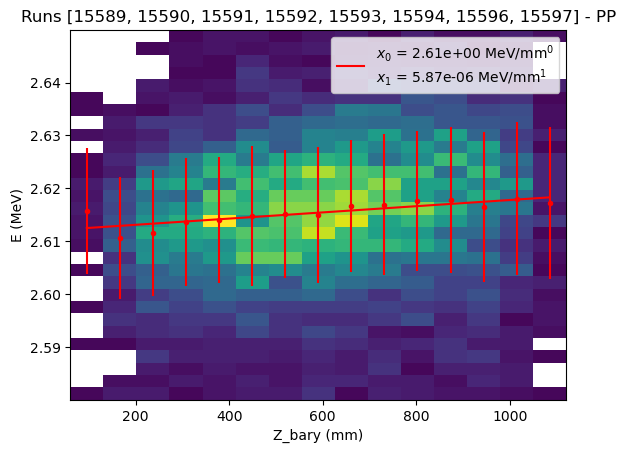

array([5.87289880e-06, 2.61190849e+00])

In [119]:
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr],dep_range)], 'Z_bary', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], pp_range)], 'Z_bary', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)


In [120]:
# plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'S1e', 'E_shifted', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), None), plotrange=((200, 400), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted_d, 1.56, 1.63)], 'S1e', 'E_shifted_d', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), None), plotrange=((200, 400), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP - drop'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted_all, 1.56, 1.63)], 'S1e', 'E_shifted_all', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), None), plotrange=((200, 400), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP - 6 peaks'.format(run_numbers), cmap=cmap)
# plot_profile(reco_summ[in_range(reco_summ.E_shifted_all_d, 1.56, 1.63)], 'S1e', 'E_shifted_all_d', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), None), plotrange=((200, 400), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP - 6peaks+drop'.format(run_numbers), cmap=cmap)


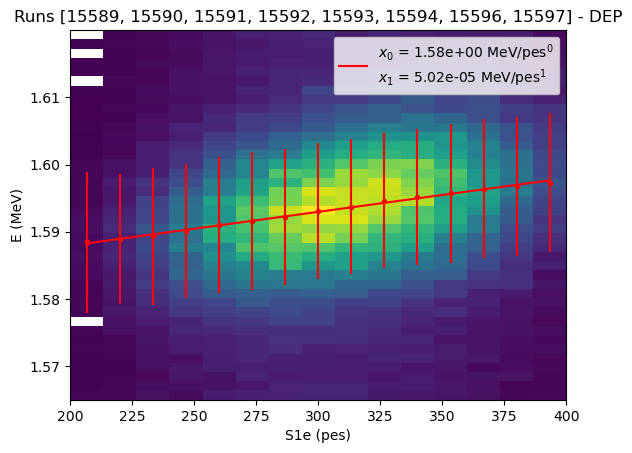

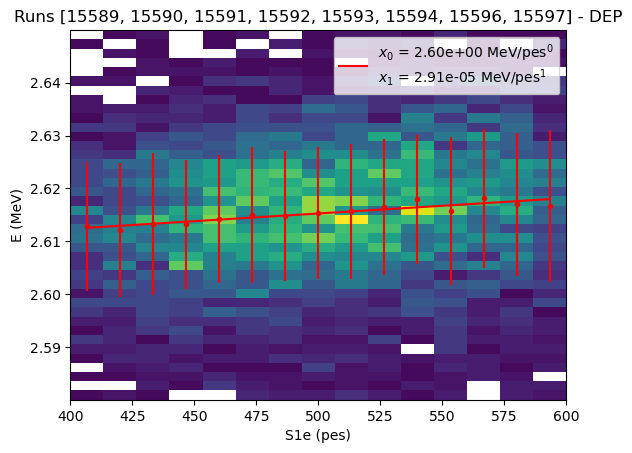

array([2.91393260e-05, 2.60068231e+00])

In [121]:
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], dep_range)], 'S1e', ene_var_corr, fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), None), plotrange=((200, 400), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], pp_range)], 'S1e', ene_var_corr, fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((400, 600), None), plotrange=((400, 600), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)


### Correct dependencies

Main dependencies: dZ, Z_bary, S1e

In [122]:
reco_summ

,event,npeak,run_n,file_n,ldc_n,time,dX,dY,dZ,Xmin,...,nhits_drop_in,Ec_drop_out,nhits_drop_out,total_energy_d,E_shifted,E_shifted_d,E_shifted_all,E_shifted_all_d,S1e,S2e
0,120,32,15589,0000,ldc1,1.751990e+09,400.30,277.40,163.531875,-19.125,...,83,0.008404,21,1.843904,1.759613,1.765271,1.758545,1.761780,335.559998,347422.250000
1,442,32,15589,0000,ldc1,1.751990e+09,107.85,107.85,63.406375,88.725,...,13,0.004922,16,0.346503,0.333067,0.337511,0.332874,0.338333,74.863655,67065.500000
2,687,21,15589,0000,ldc1,1.751990e+09,170.05,170.05,147.313125,134.375,...,74,0.006229,10,1.788487,1.704872,1.712430,1.703839,1.709099,342.572662,339142.000000
3,883,18,15589,0001,ldc1,1.751990e+09,123.40,123.40,27.127250,-328.125,...,12,0.014065,16,0.372155,0.366139,0.361969,0.365925,0.362717,92.503571,72588.984375
4,1135,36,15589,0001,ldc1,1.751990e+09,215.70,154.00,78.885000,-312.575,...,31,0.008478,14,0.747150,0.717250,0.719524,0.716821,0.719192,114.979454,147387.437500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1572737,3828076,18,15597,5370,ldc7,1.752674e+09,185.60,262.35,127.080500,-96.875,...,38,0.001844,12,0.596266,0.566791,0.574706,0.566324,0.574691,118.942566,114553.078125
1572738,3828230,22,15597,5370,ldc7,1.752674e+09,138.95,138.95,26.769250,288.875,...,22,0.006377,9,0.360555,0.347429,0.350621,0.346981,0.350936,63.060837,67069.898438
1572739,3828531,31,15597,5370,ldc7,1.752674e+09,170.05,339.10,47.254250,-81.325,...,29,0.003201,4,0.614114,0.585014,0.591673,0.584546,0.591633,126.267693,117896.054688
1572740,3828566,19,15597,5370,ldc7,1.752674e+09,123.40,462.50,71.389000,104.275,...,22,0.004064,20,0.355775,0.340698,0.346077,0.340251,0.346398,65.120125,68769.843750


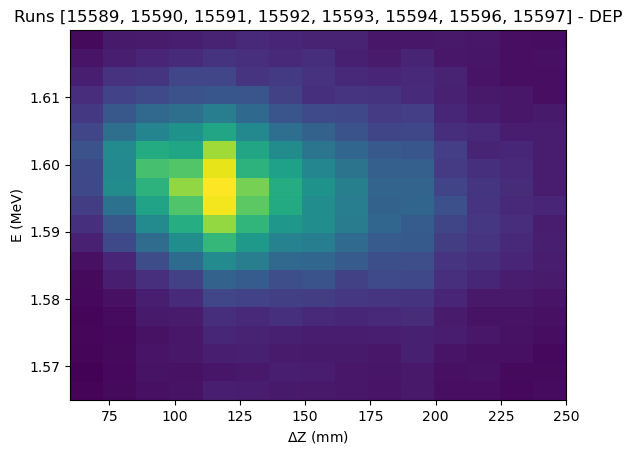

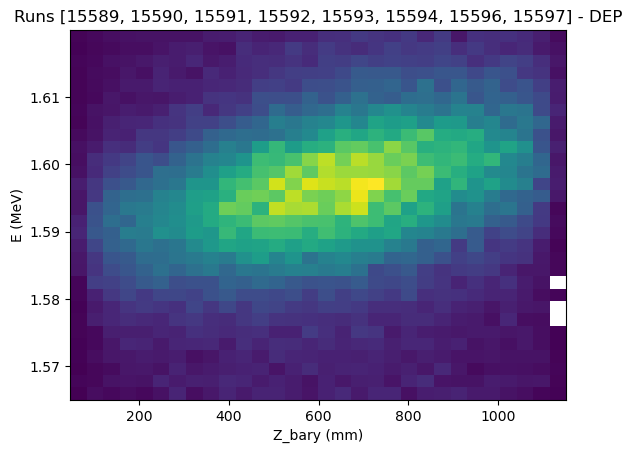

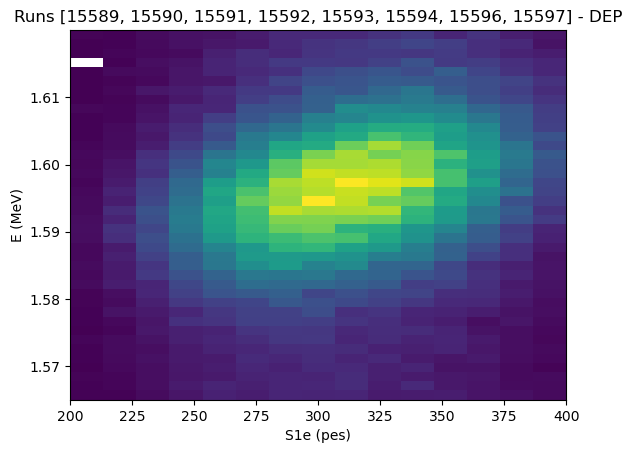

In [124]:
plot_hist2d(reco_summ[in_range(reco_summ['E_shifted'], dep_range)], 'dZ', 'E_shifted', plotbins=(15, 20), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_hist2d(reco_summ[in_range(reco_summ['E_shifted'], dep_range)], 'Z_bary', 'E_shifted', plotbins=(30, 30), plotrange=(None, None), axlabel = ['Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_hist2d(reco_summ[in_range(reco_summ['E_shifted'], dep_range)], 'S1e', 'E_shifted', plotbins=(15, 40), plotrange=((200, 400), None), axlabel = ['S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)

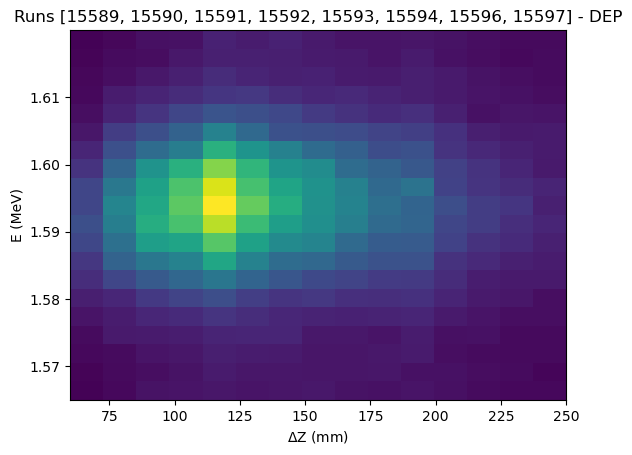

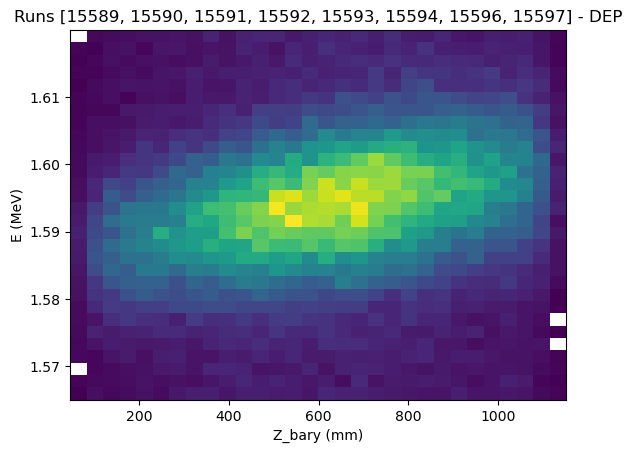

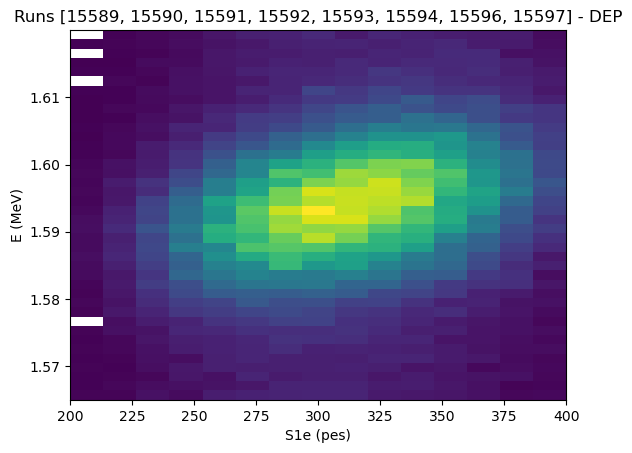

In [57]:
plot_hist2d(reco_summ[in_range(reco_summ[ene_var_corr], dep_range)], 'dZ', ene_var_corr, plotbins=(15, 20), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_hist2d(reco_summ[in_range(reco_summ[ene_var_corr], dep_range)], 'Z_bary', ene_var_corr, plotbins=(30, 30), plotrange=(None, None), axlabel = ['Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_hist2d(reco_summ[in_range(reco_summ[ene_var_corr], dep_range)], 'S1e', ene_var_corr, plotbins=(15, 40), plotrange=((200, 400), None), axlabel = ['S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)

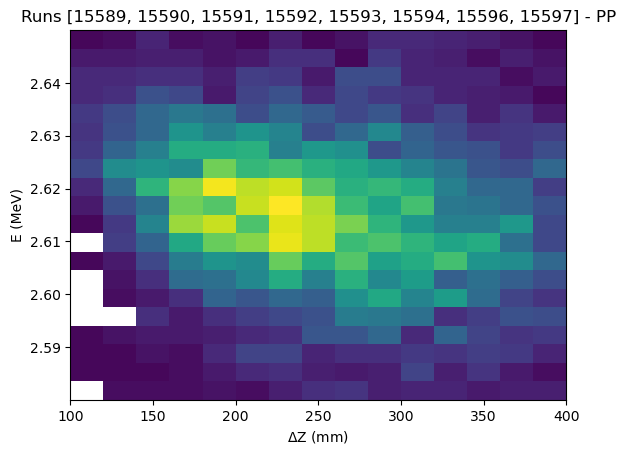

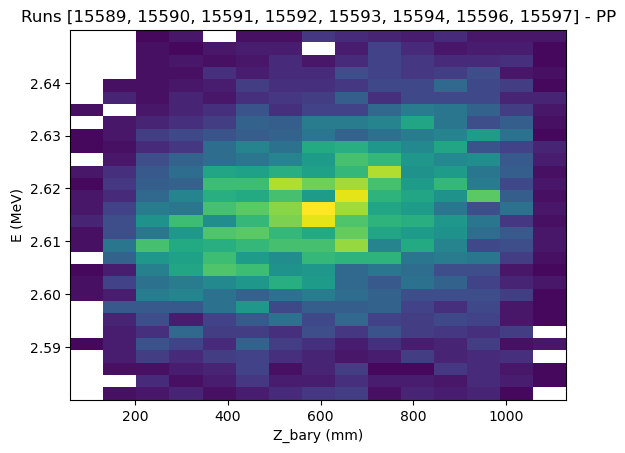

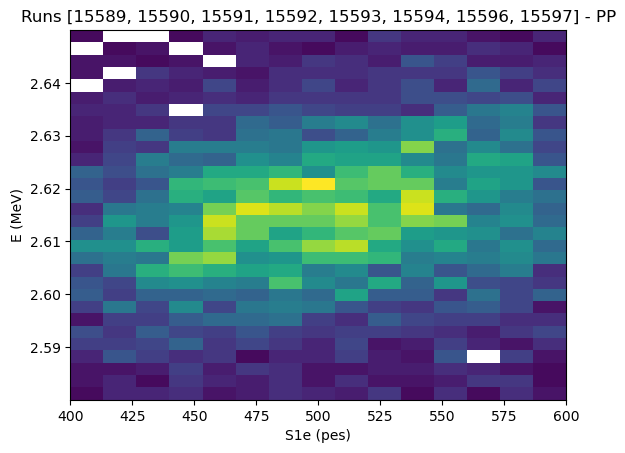

In [150]:
plot_hist2d(reco_summ[in_range(reco_summ['E_shifted'], pp_range)], 'dZ', 'E_shifted', plotbins=(15, 20), plotrange=((100, 400), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_hist2d(reco_summ[in_range(reco_summ['E_shifted'], pp_range)], 'Z_bary', 'E_shifted', plotbins=(15, 30), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_hist2d(reco_summ[in_range(reco_summ['E_shifted'], pp_range)], 'S1e', 'E_shifted', plotbins=(15, 30), plotrange=((400, 600), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)

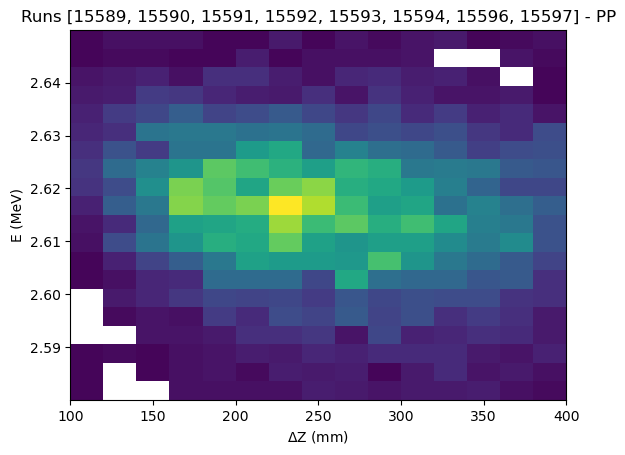

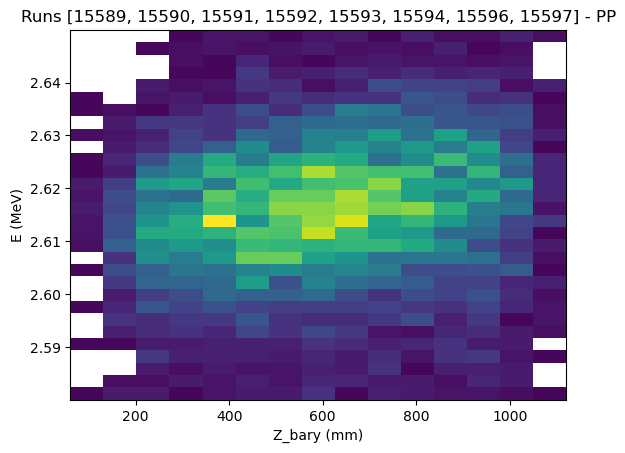

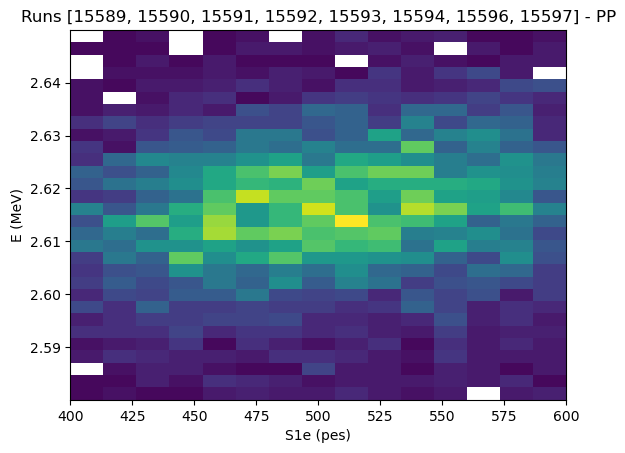

In [151]:
plot_hist2d(reco_summ[in_range(reco_summ[ene_var_corr], pp_range)], 'dZ', ene_var_corr, plotbins=(15, 20), plotrange=((100, 400), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_hist2d(reco_summ[in_range(reco_summ[ene_var_corr], pp_range)], 'Z_bary', ene_var_corr, plotbins=(15, 30), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_hist2d(reco_summ[in_range(reco_summ[ene_var_corr], pp_range)], 'S1e', ene_var_corr, plotbins=(15, 30), plotrange=((400, 600), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)

In [ ]:
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr],  pp_range)], 'dZ', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 20), fitrange=((100, 400), None), plotrange=((100, 400), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], pp_range)], 'Z_bary', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], pp_range)], 'S1e', ene_var_corr, fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((400, 600), None), plotrange=((400, 600), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)

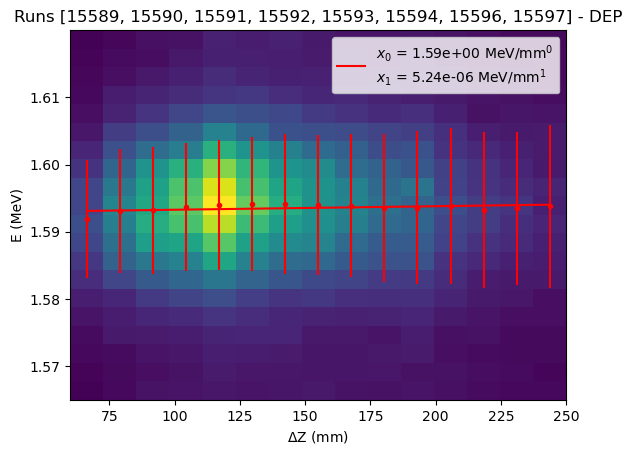

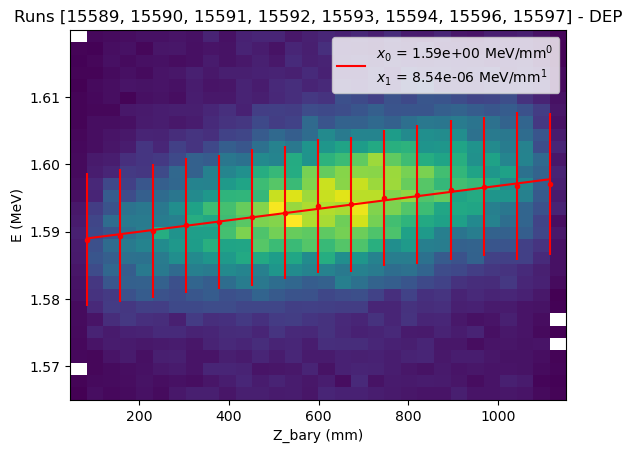

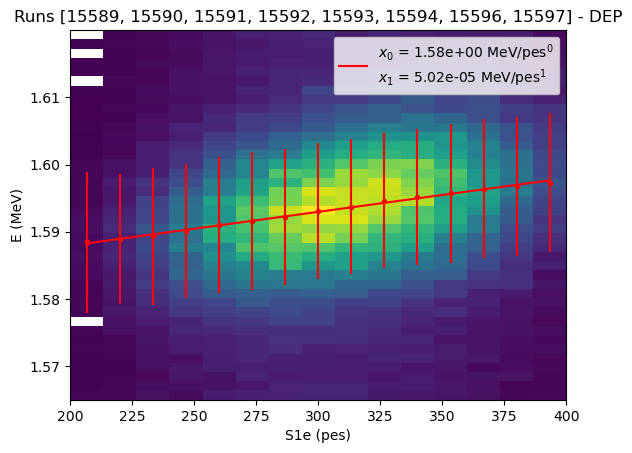

array([5.02170899e-05, 1.57789292e+00])

In [49]:
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], dep_range)], 'dZ', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 20), fitrange=((60, 250), None), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], dep_range)], 'Z_bary', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], dep_range)], 'S1e', ene_var_corr, fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), None), plotrange=((200, 400), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)


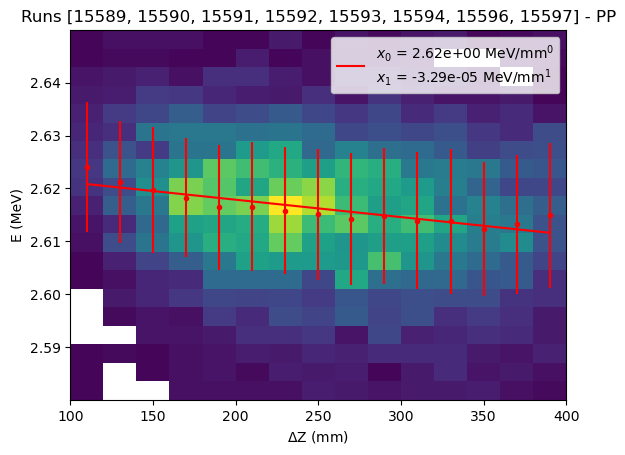

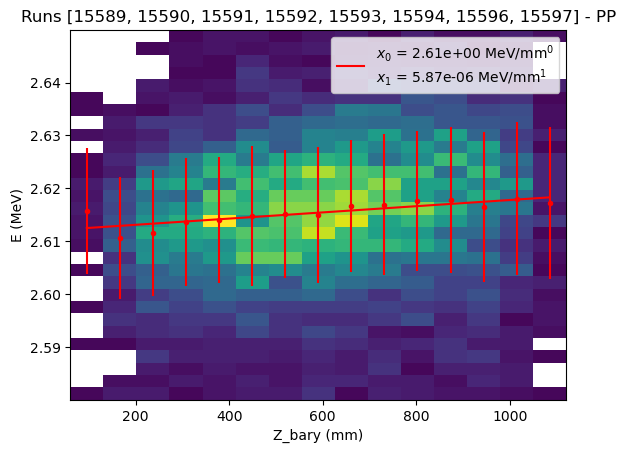

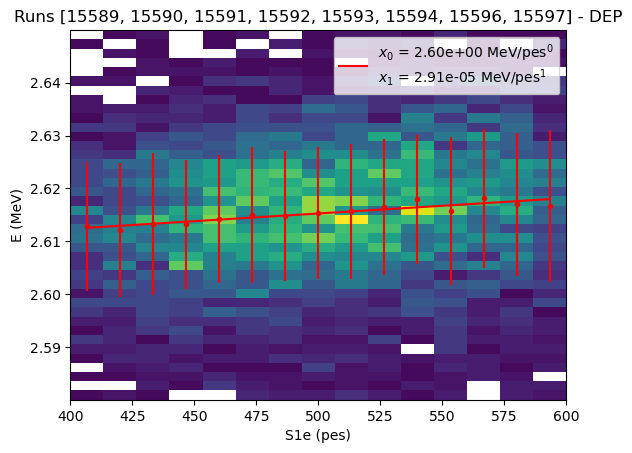

array([2.91393260e-05, 2.60068231e+00])

In [50]:
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr],  pp_range)], 'dZ', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 20), fitrange=((100, 400), None), plotrange=((100, 400), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], pp_range)], 'Z_bary', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], pp_range)], 'S1e', ene_var_corr, fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((400, 600), None), plotrange=((400, 600), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)

Correct dZ

In [51]:
# par_DEP_dZ = plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'dZ', 'E_shifted', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=10, plotbins=(10, 20), fitrange=((60, 250), None), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# par_DEP_dZ_d = plot_profile(reco_summ[in_range(reco_summ.E_shifted_d, 1.56, 1.63)], 'dZ', 'E_shifted_d', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=10, plotbins=(10, 20), fitrange=((60, 250), None), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# par_DEP_dZ_all = plot_profile(reco_summ[in_range(reco_summ.E_shifted_all, 1.56, 1.63)], 'dZ', 'E_shifted_all', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=10, plotbins=(10, 20), fitrange=((60, 250), None), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# par_DEP_dZ_all_d = plot_profile(reco_summ[in_range(reco_summ.E_shifted_all_d, 1.57, 1.62)], 'dZ', 'E_shifted_all_d', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=10, plotbins=(10, 20), fitrange=((60, 250), None), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)

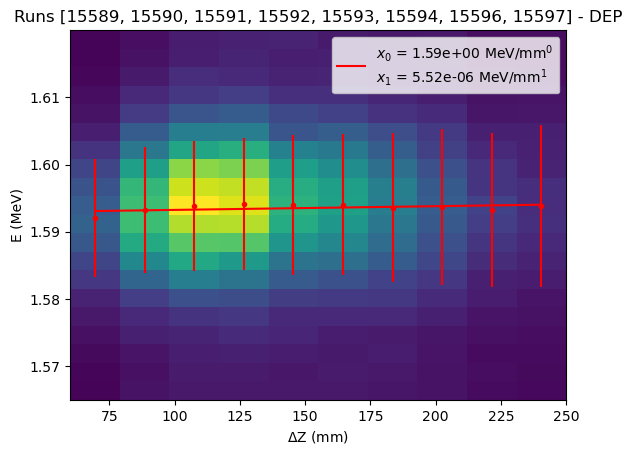

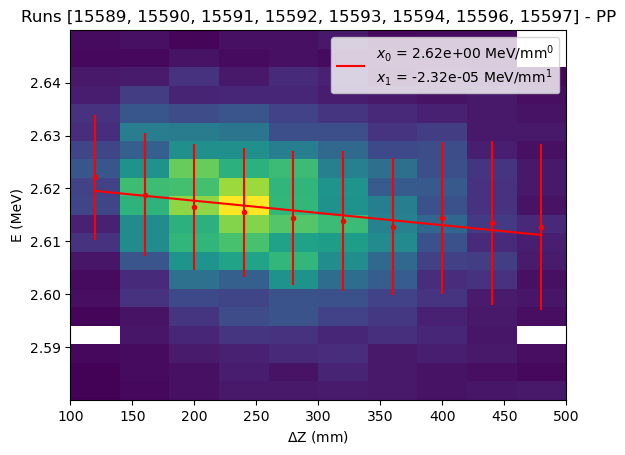

In [126]:
par_DEP_dZ = plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], dep_range)], 'dZ', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=10, plotbins=(10, 20), fitrange=((60, 250), None), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
par_PP_dZ = plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], pp_range)], 'dZ', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=10, plotbins=(10, 20), fitrange=((100, 500), None), plotrange=((100, 500), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)


In [127]:
# dp_correct = reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)].copy()
# pp_correct = reco_summ[in_range(reco_summ.E_shifted, 2.58, 2.65)].copy()

# # dp_correct['E_dZ'] =  dp_correct.E_shifted / (1 + (par_DEP_dZ[0] / par_DEP_dZ[1]) * dp_correct.dZ)
# # dp_correct['E_dZ_d'] =  dp_correct.E_shifted_d / (1 + (par_DEP_dZ_d[0] / par_DEP_dZ_d[1]) * dp_correct.dZ)
# # dp_correct['E_dZ_all'] =  dp_correct.E_shifted_all / (1 + (par_DEP_dZ_all[0] / par_DEP_dZ_all[1]) * dp_correct.dZ)
# # dp_correct['E_dZ_all_d'] =  dp_correct.E_shifted_all_d / (1 + (par_DEP_dZ_all_d[0] / par_DEP_dZ_all_d[1]) * dp_correct.dZ)

# # pp_correct['E_dZ'] =  pp_correct.E_shifted / (1 + (par_DEP_dZ[0] / par_DEP_dZ[1]) * pp_correct.dZ)
# # pp_correct['E_dZ_d'] =  pp_correct.E_shifted_d / (1 + (par_DEP_dZ_d[0] / par_DEP_dZ_d[1]) * pp_correct.dZ)
# # pp_correct['E_dZ_all'] =  pp_correct.E_shifted_all / (1 + (par_DEP_dZ_all[0] / par_DEP_dZ_all[1]) * pp_correct.dZ)
# # pp_correct['E_dZ_all_d'] =  pp_correct.E_shifted_all_d / (1 + (par_DEP_dZ_all_d[0] / par_DEP_dZ_all_d[1]) * pp_correct.dZ)

# pp_correct['E_PP_dZ'] =  pp_correct.E_shifted / (1 + (par_PP_dZ[0] / par_PP_dZ[1]) * pp_correct.dZ)

In [128]:
dp_correct = reco_summ[in_range(reco_summ[ene_var_corr], dep_range)].copy()
pp_correct = reco_summ[in_range(reco_summ[ene_var_corr], pp_range)].copy()

# NO CORRECT IN DZ FOR DEP
dp_correct['E_dZ'] =  dp_correct[ene_var_corr] #/ (1 + (par_DEP_dZ[0] / par_DEP_dZ[1]) * dp_correct.dZ)
pp_correct['E_dZ'] =  pp_correct[ene_var_corr] / (1 + (par_PP_dZ[0] / par_PP_dZ[1]) * pp_correct.dZ)

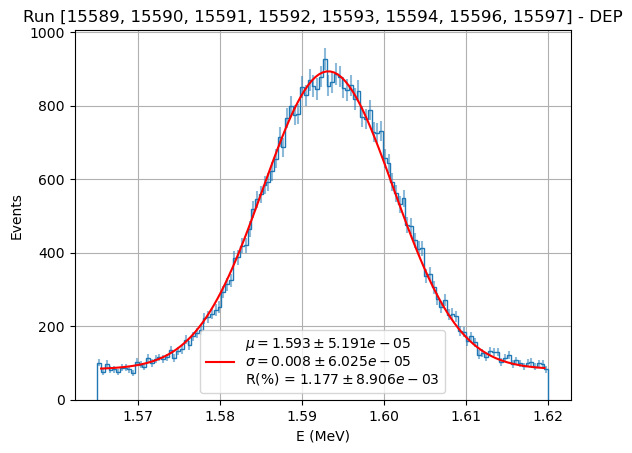

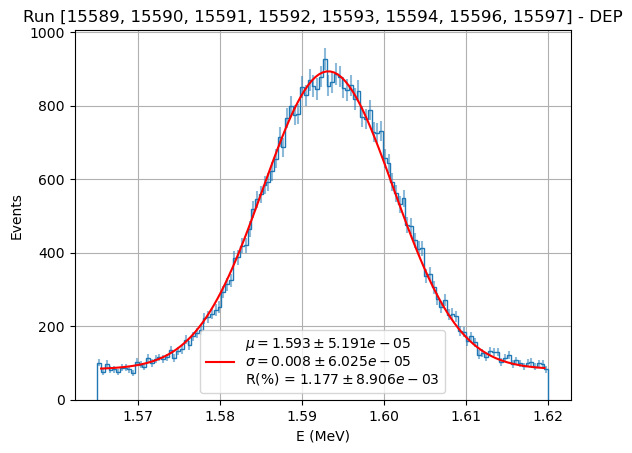

Energy resolution DEP: 1.177 ± 0.009 %
Energy resolution DEP (dZ corr): 1.177 ± 0.009 %


In [129]:
_, r_dep = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, dep_range, 120, title = 'Run {} - '.format(run_numbers) + 'DEP', plot = True)
plt.show()
_, r_dep_dZ = fit_whole_peaks(dp_correct[dp_correct.Rmax < 400], 'E_dZ', peak_fit, dep_range, 120, title = 'Run {} - '.format(run_numbers) + 'DEP', plot = True)
plt.show()

print('Energy resolution DEP: {:.3f} ± {:.3f} %'.format(r_dep[0], r_dep[1]))
print('Energy resolution DEP (dZ corr): {:.3f} ± {:.3f} %'.format(r_dep_dZ[0], r_dep_dZ[1]))


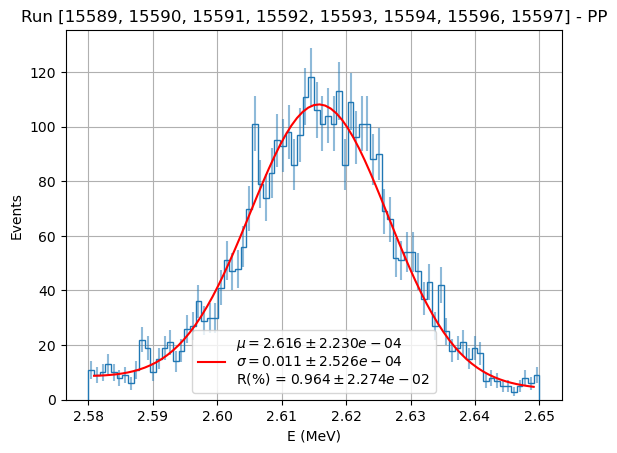

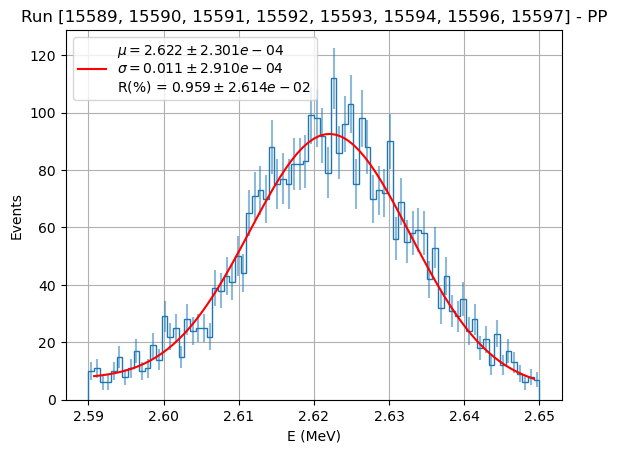

Energy resolution PP: 0.964 ± 0.023 %
Energy resolution PP (dZ corr): 0.959 ± 0.026 %


In [130]:
_, r_pp = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, pp_range, 80, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True)
plt.show()
_, r_pp_dZ = fit_whole_peaks(pp_correct[pp_correct.Rmax < 400], 'E_dZ', peak_fit, (2.59, 2.65), 80, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True)
plt.show()


print('Energy resolution PP: {:.3f} ± {:.3f} %'.format(r_pp[0], r_pp[1]))
print('Energy resolution PP (dZ corr): {:.3f} ± {:.3f} %'.format(r_pp_dZ[0], r_pp_dZ[1]))

### El PP igualmente me cuesta que mejore corrigiendo en dZ... Tengo que andar jugando mucho con el rango de plot, lo cual no me gusta demasiado........ (por ejemplo, si pongo el mismo rango sale peor, si pongo (2.59, 2.655) sale exactamente igual, si pongo (2.59, 2.65) sale mejor......)

Corrected dZ!

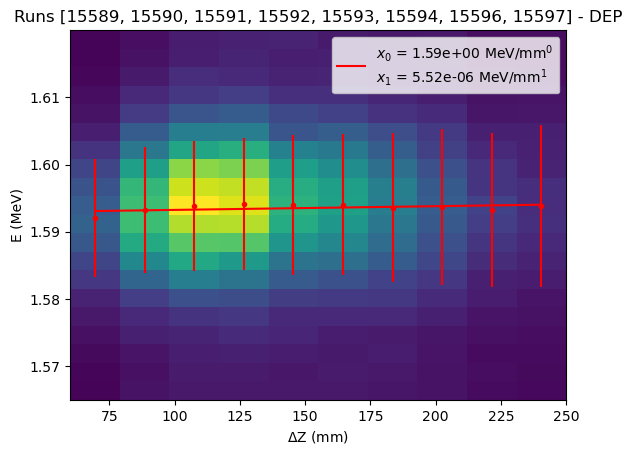

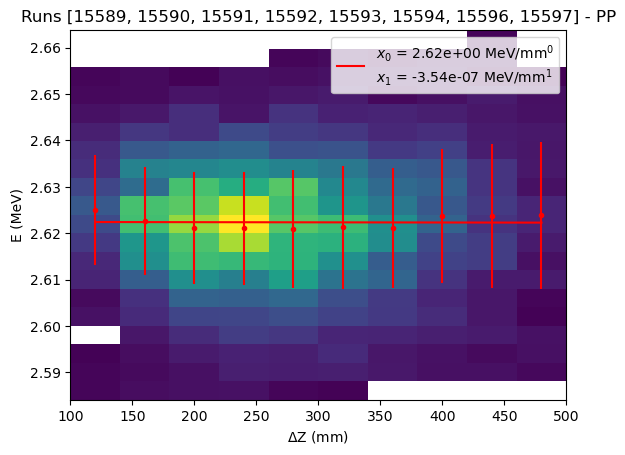

array([-3.54103227e-07,  2.62244484e+00])

In [131]:
plot_profile(dp_correct, 'dZ', 'E_dZ', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=10, plotbins=(10, 20), fitrange=((60, 250), None), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_profile(pp_correct, 'dZ', 'E_dZ', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=10, plotbins=(10, 20), fitrange=((100, 500), None), plotrange=((100, 500), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)


Did the other dependencies improve?

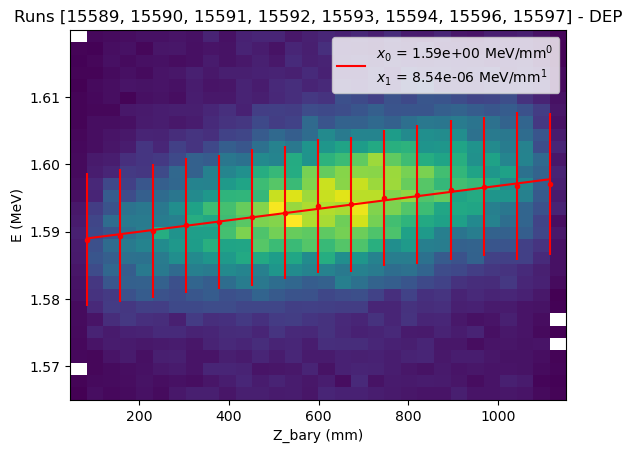

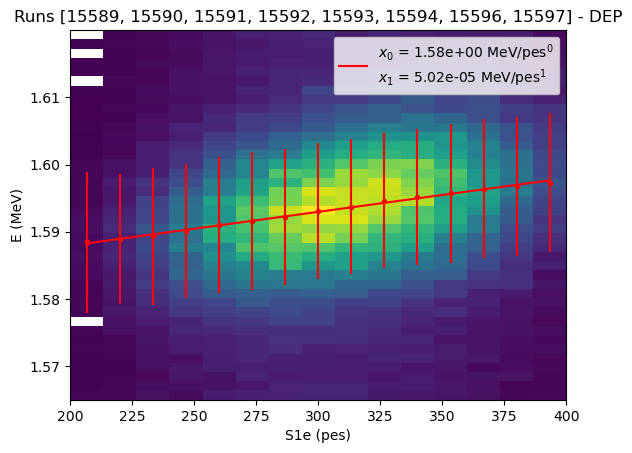

array([5.02170899e-05, 1.57789292e+00])

In [132]:
plot_profile(dp_correct, 'Z_bary', 'E_dZ', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_profile(dp_correct, 'S1e', 'E_dZ', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), None), plotrange=((200, 400), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)


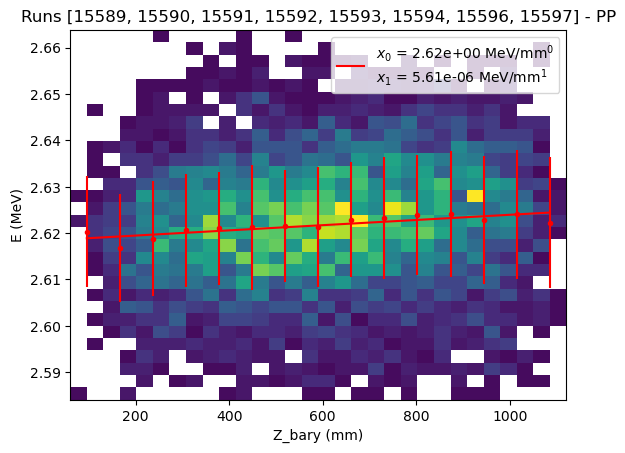

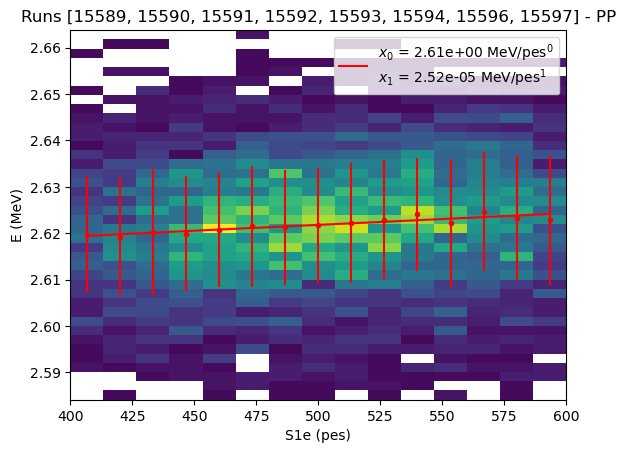

array([2.51536083e-05, 2.60921180e+00])

In [133]:
plot_profile(pp_correct, 'Z_bary', 'E_dZ', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_profile(pp_correct, 'S1e', 'E_dZ', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((400, 600), None), plotrange=((400, 600), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)


Correct in Z_bary

In [134]:
# par_Z = plot_profile(dp_correct, 'Z_bary', 'E_dZ', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=30, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = ['Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# par_Z_d = plot_profile(dp_correct, 'Z_bary', 'E_dZ_d', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=30, plotbins=(30, 30), fitrange=(None, (1.56, 1.63)), plotrange=(None, (1.56, 1.63)), axlabel = ['Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# par_Z_all = plot_profile(dp_correct, 'Z_bary', 'E_dZ_all', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=30, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = ['Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# par_Z_all_d = plot_profile(dp_correct, 'Z_bary', 'E_dZ_all_d', fitfun=lineal, initial_values=(0, 1.67), std = False, fitbins=30, plotbins=(30, 30), fitrange=(None, (1.56, 1.63)), plotrange=(None, (1.56, 1.63)), axlabel = ['Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)


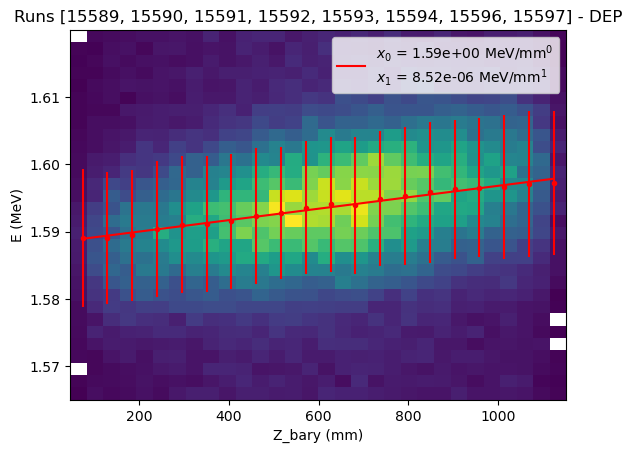

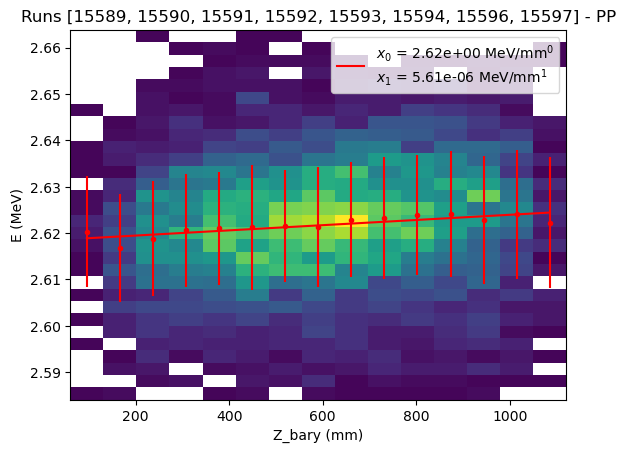

In [152]:
par_DEP_Z = plot_profile(dp_correct, 'Z_bary', 'E_dZ', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=20, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = ['Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
par_PP_Z = plot_profile(pp_correct, 'Z_bary', 'E_dZ', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 30), fitrange=(None, None), plotrange=(None, None), axlabel = ['Z_bary', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)


In [ ]:
# dp_correct['E_Z'] =  dp_correct.E_dZ / (1 + (par_Z[0] / par_Z[1]) * dp_correct.Z_bary)
# dp_correct['E_Z_d'] =  dp_correct.E_dZ_d / (1 + (par_Z_d[0] / par_Z_d[1]) * dp_correct.Z_bary)
# dp_correct['E_Z_all'] =  dp_correct.E_dZ_all / (1 + (par_Z_all[0] / par_Z_all[1]) * dp_correct.Z_bary)
# dp_correct['E_Z_all_d'] =  dp_correct.E_dZ_all_d / (1 + (par_Z_all_d[0] / par_Z_all_d[1]) * dp_correct.Z_bary)

# pp_correct['E_Z'] =  pp_correct.E_dZ / (1 + (par_Z[0] / par_Z[1]) * pp_correct.Z_bary)
# pp_correct['E_Z_d'] =  pp_correct.E_dZ_d / (1 + (par_Z_d[0] / par_Z_d[1]) * pp_correct.Z_bary)
# pp_correct['E_Z_all'] =  pp_correct.E_dZ_all / (1 + (par_Z_all[0] / par_Z_all[1]) * pp_correct.Z_bary)
# pp_correct['E_Z_all_d'] =  pp_correct.E_dZ_all_d / (1 + (par_Z_all_d[0] / par_Z_all_d[1]) * pp_correct.Z_bary)

In [154]:
dp_correct['E_Z'] =  dp_correct['E_dZ'] / (1 + (par_DEP_Z[0] / par_DEP_Z[1]) * dp_correct.Z_bary)
pp_correct['E_Z'] =  pp_correct['E_dZ'] / (1 + (par_PP_Z[0] / par_PP_Z[1]) * pp_correct.Z_bary)

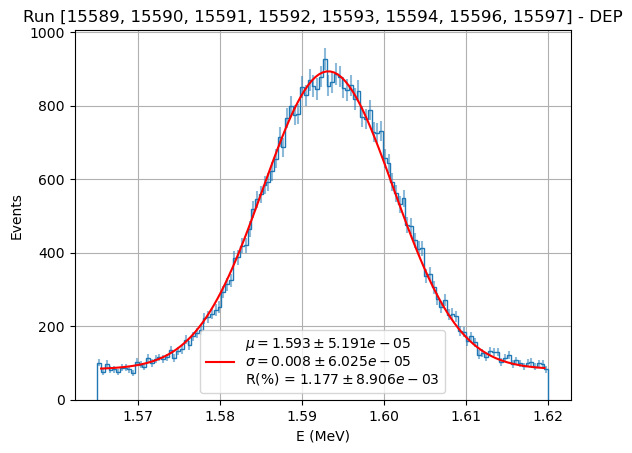

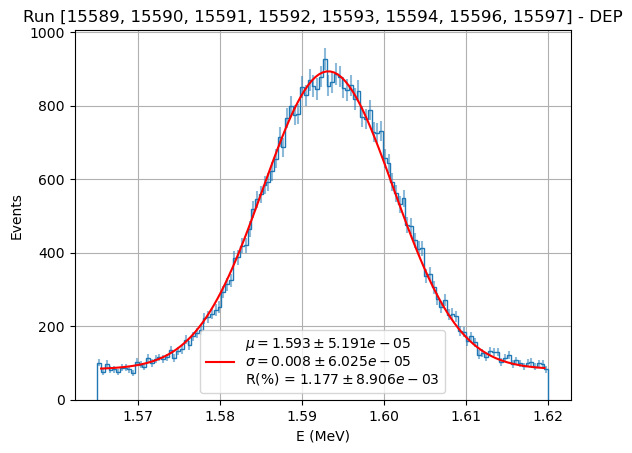

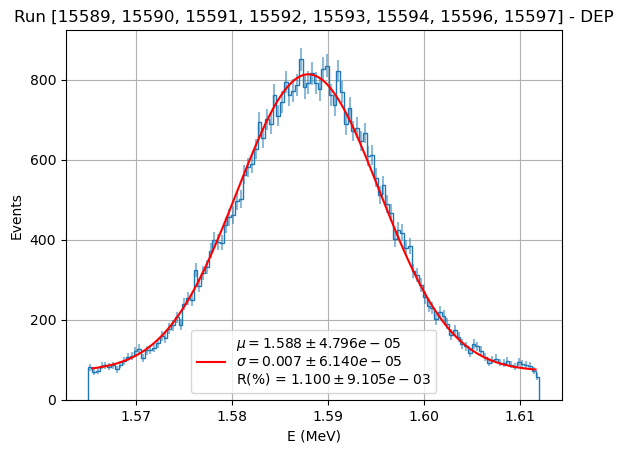

Energy resolution DEP: 1.177 ± 0.009 %
Energy resolution DEP (dZ corr): 1.177 ± 0.009 %
Energy resolution DEP (dZ + Z corr): 1.100 ± 0.009 %


In [155]:
_, r_dep = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, dep_range, 120, title = 'Run {} - '.format(run_numbers) + 'DEP', plot = True)
plt.show()
_, r_dep_dZ = fit_whole_peaks(dp_correct[dp_correct.Rmax < 400], 'E_dZ', peak_fit, dep_range, 120, title = 'Run {} - '.format(run_numbers) + 'DEP', plot = True)
plt.show()
_, r_dep_dZ_Z = fit_whole_peaks(dp_correct[dp_correct.Rmax < 400], 'E_Z', peak_fit, (1.565, 1.612), 120, title = 'Run {} - '.format(run_numbers) + 'DEP', plot = True)
plt.show()

print('Energy resolution DEP: {:.3f} ± {:.3f} %'.format(r_dep[0], r_dep[1]))
print('Energy resolution DEP (dZ corr): {:.3f} ± {:.3f} %'.format(r_dep_dZ[0], r_dep_dZ[1]))
print('Energy resolution DEP (dZ + Z corr): {:.3f} ± {:.3f} %'.format(r_dep_dZ_Z[0], r_dep_dZ_Z[1]))

In [156]:
pp_range

(2.58, 2.65)

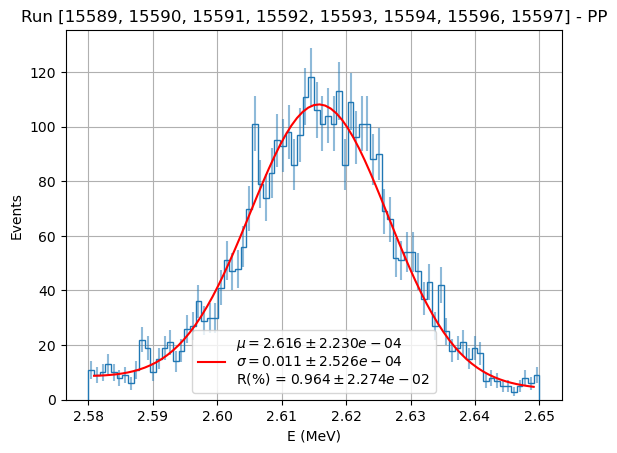

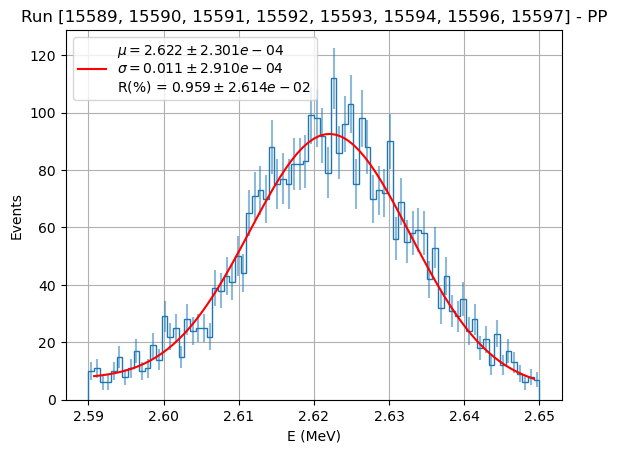

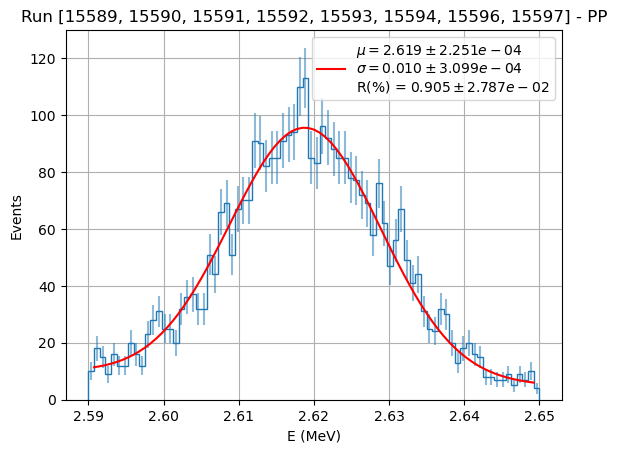

Energy resolution PP: 0.964 ± 0.023 %
Energy resolution PP (dZ corr): 0.959 ± 0.026 %
Energy resolution PP (dZ + Z corr): 0.905 ± 0.028 %


In [157]:
_, r_pp = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, pp_range, 80, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True)
plt.show()
_, r_pp_dZ = fit_whole_peaks(pp_correct[pp_correct.Rmax < 400], 'E_dZ', peak_fit, (2.59, 2.65), 80, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True)
plt.show()
_, r_pp_Z = fit_whole_peaks(pp_correct[pp_correct.Rmax < 400], 'E_Z', peak_fit, (2.59, 2.65), 80, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True)
plt.show()


print('Energy resolution PP: {:.3f} ± {:.3f} %'.format(r_pp[0], r_pp[1]))
print('Energy resolution PP (dZ corr): {:.3f} ± {:.3f} %'.format(r_pp_dZ[0], r_pp_dZ[1]))
print('Energy resolution PP (dZ + Z corr): {:.3f} ± {:.3f} %'.format(r_pp_Z[0], r_pp_Z[1]))

Corrected in Z_bary!

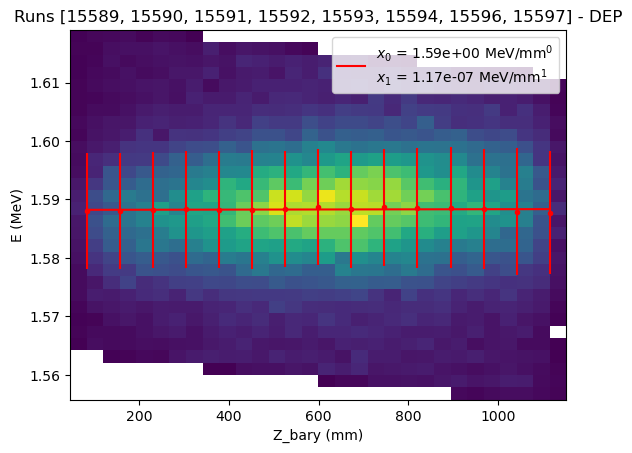

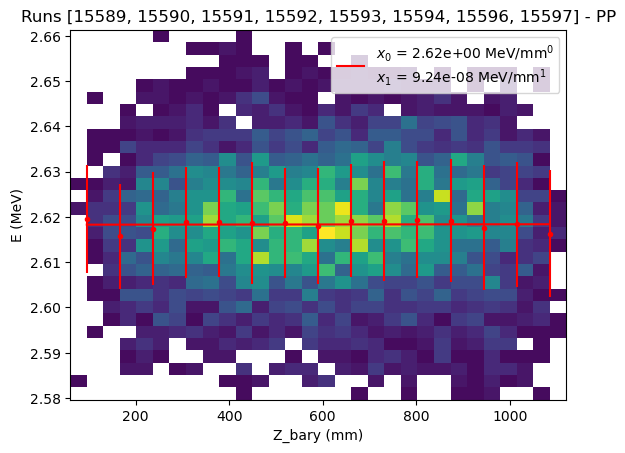

array([9.23768961e-08, 2.61827467e+00])

In [158]:
plot_profile(dp_correct, 'Z_bary', 'E_Z', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_profile(pp_correct, 'Z_bary', 'E_Z', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)


dZ correction doesn't seem to get worse

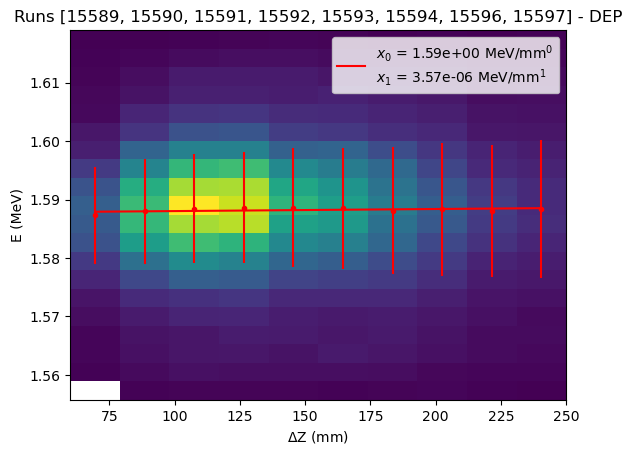

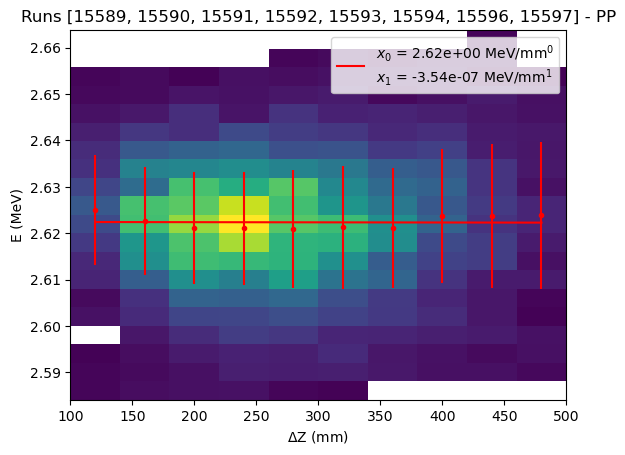

array([-3.54103227e-07,  2.62244484e+00])

In [159]:
plot_profile(dp_correct, 'dZ', 'E_Z', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=10, plotbins=(10, 20), fitrange=((60, 250), None), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_profile(pp_correct, 'dZ', 'E_dZ', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=10, plotbins=(10, 20), fitrange=((100, 500), None), plotrange=((100, 500), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)

S1e dependencies improve a bit

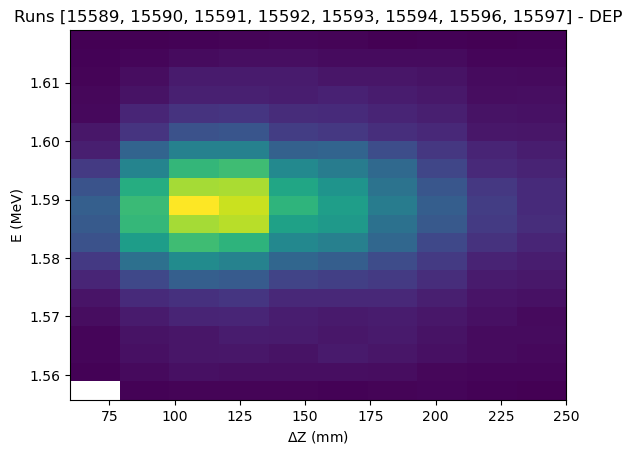

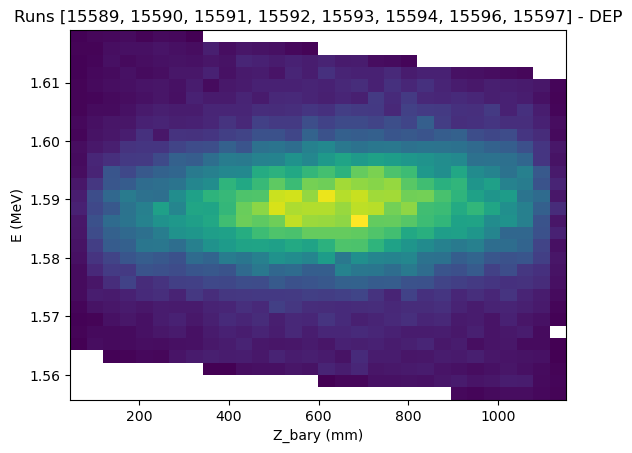

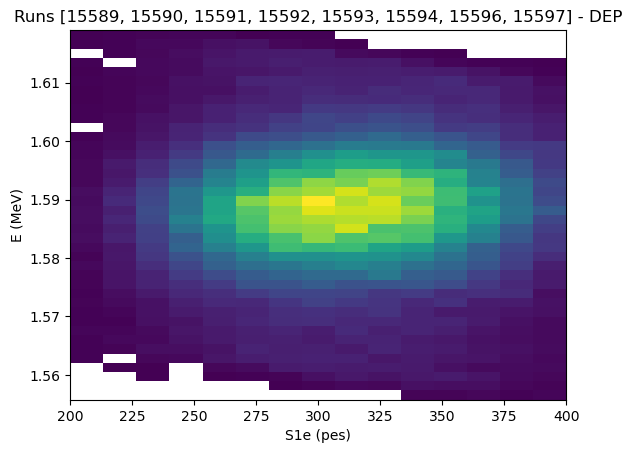

In [160]:
plot_hist2d(dp_correct, 'dZ', 'E_Z', plotbins=(10, 20), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_hist2d(dp_correct, 'Z_bary', 'E_Z', plotbins=(30, 30), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_hist2d(dp_correct, 'S1e', 'E_Z', plotbins=(15, 40), plotrange=((200, 400), None), axlabel = ['S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)


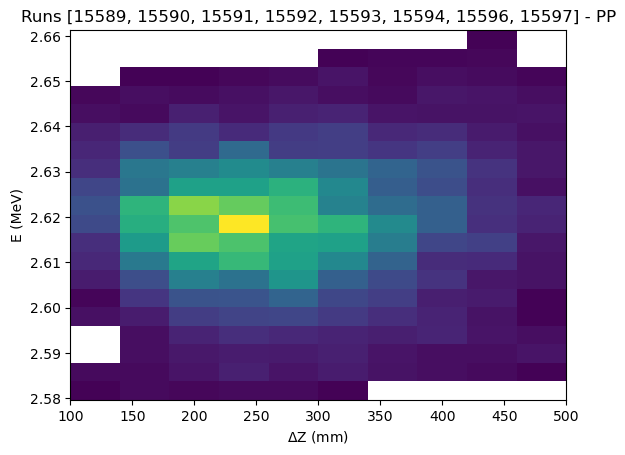

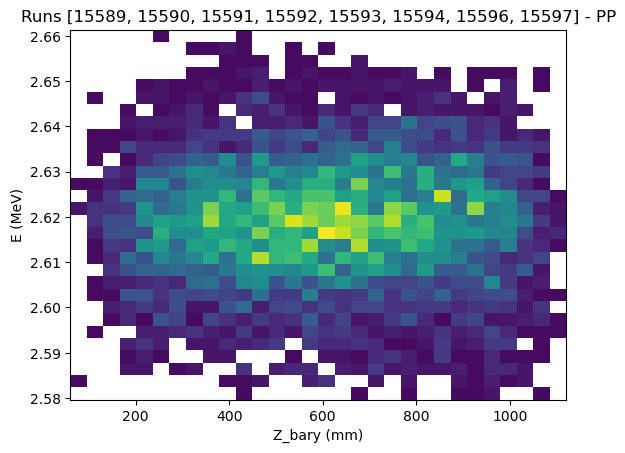

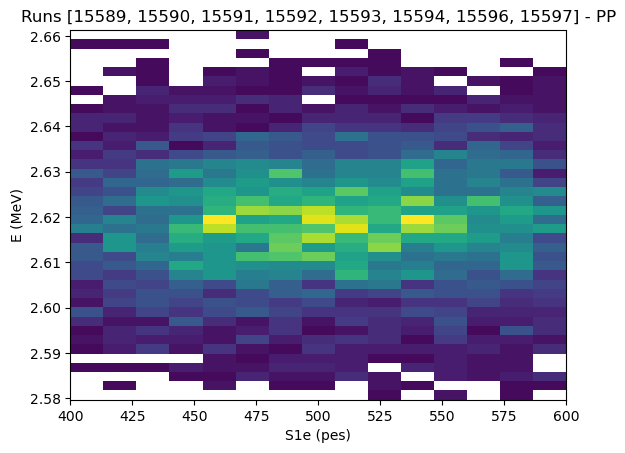

In [161]:
plot_hist2d(pp_correct, 'dZ', 'E_Z', plotbins=(10, 20), plotrange=((100, 500), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_hist2d(pp_correct, 'Z_bary', 'E_Z', plotbins=(30, 30), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_hist2d(pp_correct, 'S1e', 'E_Z', plotbins=(15, 40), plotrange=((400, 600), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)


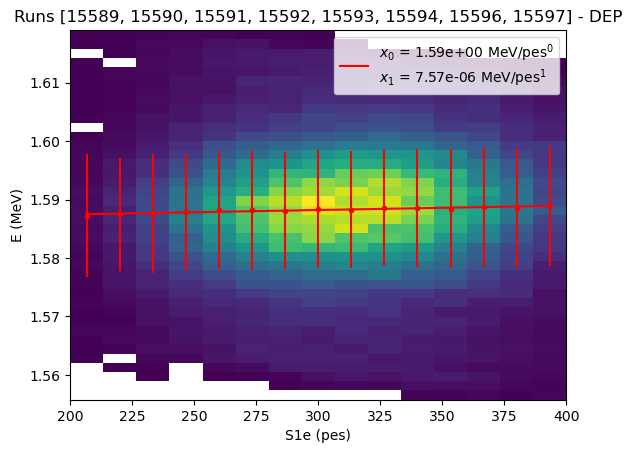

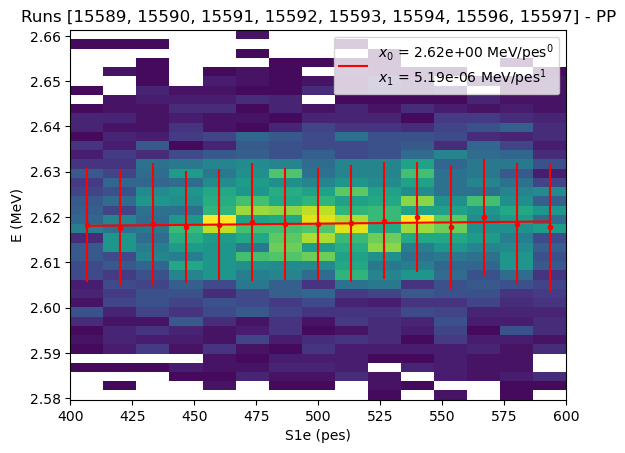

array([5.18728923e-06, 2.61594499e+00])

In [139]:
plot_profile(dp_correct, 'S1e', 'E_Z', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), None), plotrange=((200, 400), None), axlabel = ['S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_profile(pp_correct, 'S1e', 'E_Z', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((400, 600), None), plotrange=((400, 600), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)


Correct S1e (although it seems to get better after previous corrections)

In [84]:
# par_S1e = plot_profile(dp_correct, 'S1e', 'E_Z', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), (1.56, 1.63)), plotrange=((200, 400), (1.56, 1.63)), axlabel = ['S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# par_S1e_d = plot_profile(dp_correct, 'S1e', 'E_Z_d', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), (1.56, 1.63)), plotrange=((200, 400), (1.56, 1.63)), axlabel = ['S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# par_S1e_all = plot_profile(dp_correct, 'S1e', 'E_Z_all', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), (1.56, 1.63)), plotrange=((200, 400), (1.56, 1.63)), axlabel = ['S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
# par_S1e_all_d = plot_profile(dp_correct, 'S1e', 'E_Z_all_d', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), (1.56, 1.63)), plotrange=((200, 400), (1.56, 1.63)), axlabel = ['S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)


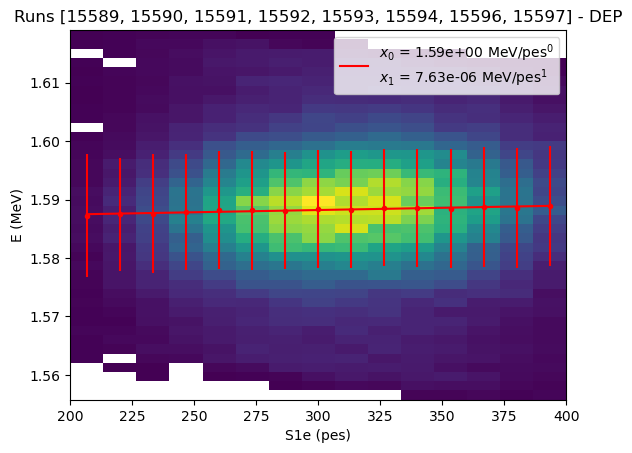

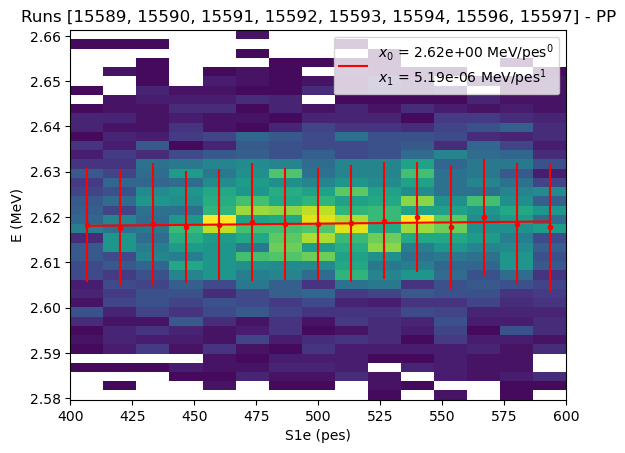

In [87]:
par_DEP_S1e = plot_profile(dp_correct, 'S1e', 'E_Z', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), None), plotrange=((200, 400), None), axlabel = ['S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
par_PP_S1e = plot_profile(pp_correct, 'S1e', 'E_Z', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((400, 600), None), plotrange=((400, 600), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)

In [ ]:
# dp_correct['E_S1e'] =  dp_correct.E_Z / (1 + (par_S1e[0] / par_S1e[1]) * dp_correct.S1e)
# dp_correct['E_S1e_d'] =  dp_correct.E_Z_d / (1 + (par_S1e_d[0] / par_S1e_d[1]) * dp_correct.S1e)
# dp_correct['E_S1e_all'] =  dp_correct.E_Z_all / (1 + (par_S1e_all[0] / par_S1e_all[1]) * dp_correct.S1e)
# dp_correct['E_S1e_all_d'] =  dp_correct.E_Z_all_d / (1 + (par_S1e_all_d[0] / par_S1e_all_d[1]) * dp_correct.S1e)

# pp_correct['E_S1e'] =  pp_correct.E_Z / (1 + (par_S1e[0] / par_S1e[1]) * pp_correct.S1e)
# pp_correct['E_S1e_d'] =  pp_correct.E_Z_d / (1 + (par_S1e_d[0] / par_S1e_d[1]) * pp_correct.S1e)
# pp_correct['E_S1e_all'] =  pp_correct.E_Z_all / (1 + (par_S1e_all[0] / par_S1e_all[1]) * pp_correct.S1e)
# pp_correct['E_S1e_all_d'] =  pp_correct.E_Z_all_d / (1 + (par_S1e_all_d[0] / par_S1e_all_d[1]) * pp_correct.S1e)

In [88]:
dp_correct['E_S1e'] =  dp_correct['E_Z'] / (1 + (par_DEP_S1e[0] / par_DEP_S1e[1]) * dp_correct.S1e)
pp_correct['E_S1e'] =  pp_correct['E_Z'] / (1 + (par_PP_S1e[0] / par_PP_S1e[1]) * pp_correct.S1e)

Corrected by S1e

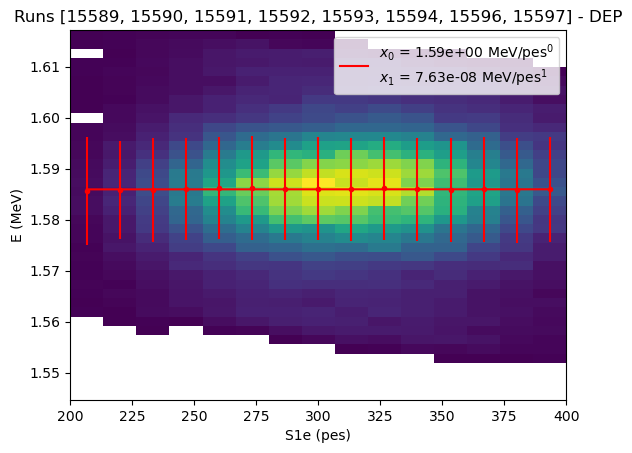

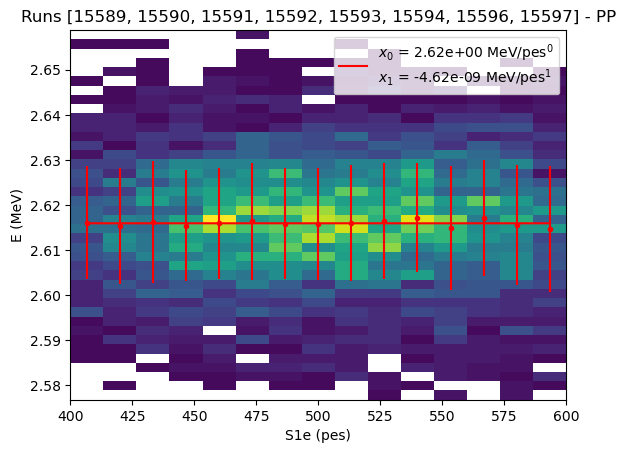

array([-4.62166030e-09,  2.61594721e+00])

In [89]:
plot_profile(dp_correct, 'S1e', 'E_S1e', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), None), plotrange=((200, 400), None), axlabel = ['S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_profile(pp_correct, 'S1e', 'E_S1e', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((400, 600), None), plotrange=((400, 600), None), axlabel = ['S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)

Does it change other corrections?

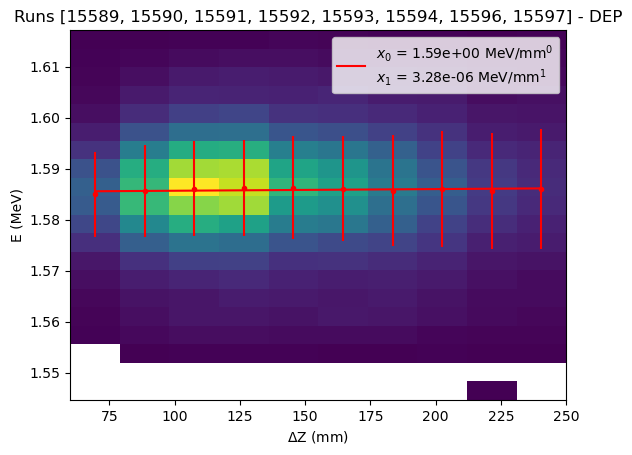

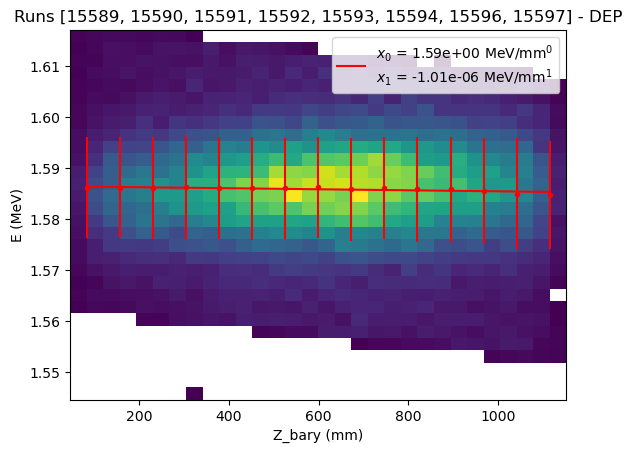

array([-1.00603966e-06,  1.58651524e+00])

In [90]:
plot_profile(dp_correct, 'dZ', 'E_S1e', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=10, plotbins=(10, 20), fitrange=((60, 250), None), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_profile(dp_correct, 'Z_bary', 'E_S1e', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)

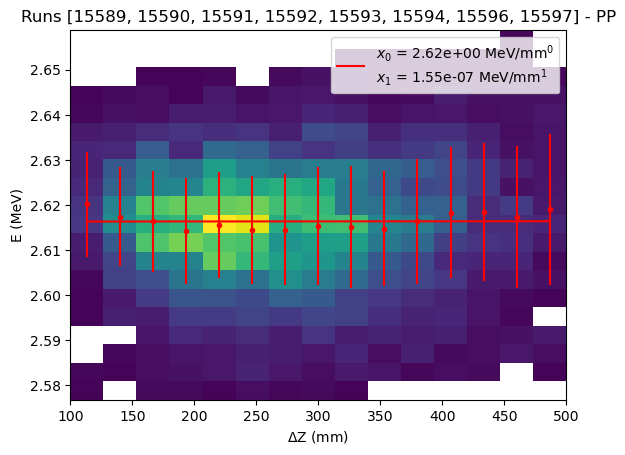

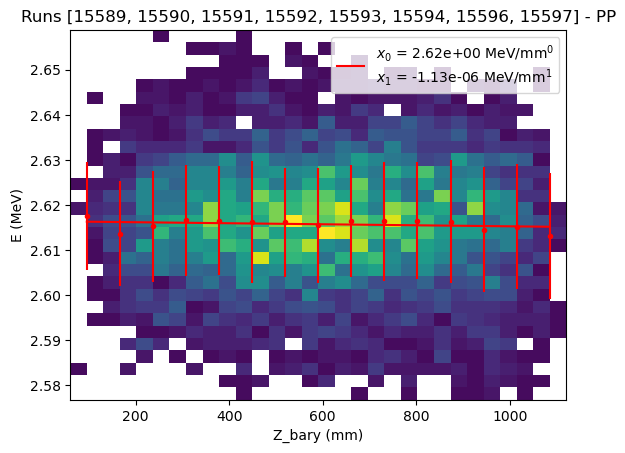

array([-1.13167003e-06,  2.61637873e+00])

In [94]:
plot_profile(pp_correct, 'dZ', 'E_S1e', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 20), fitrange=((100, 500), None), plotrange=((100, 500), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_profile(pp_correct, 'Z_bary', 'E_S1e', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)

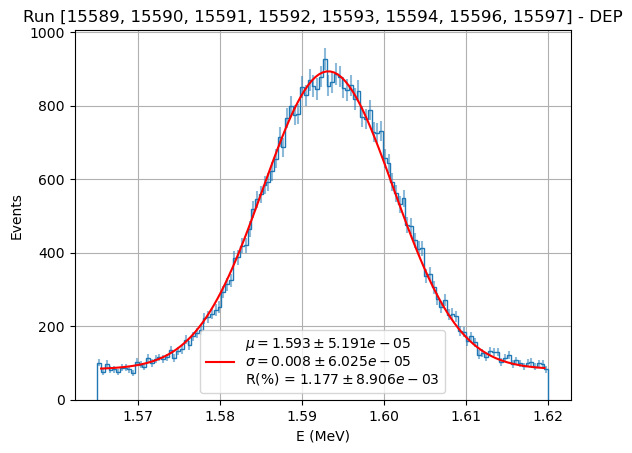

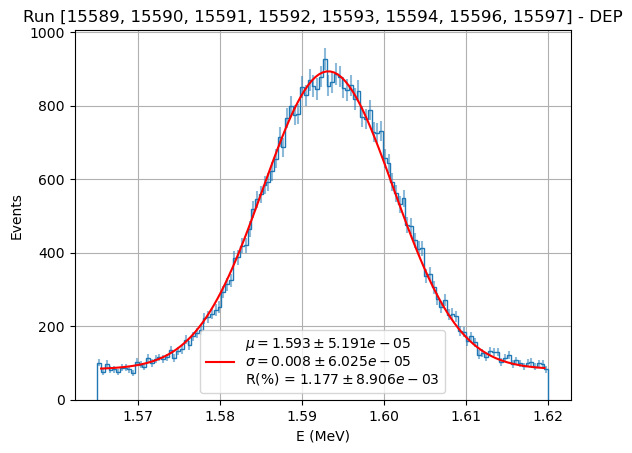

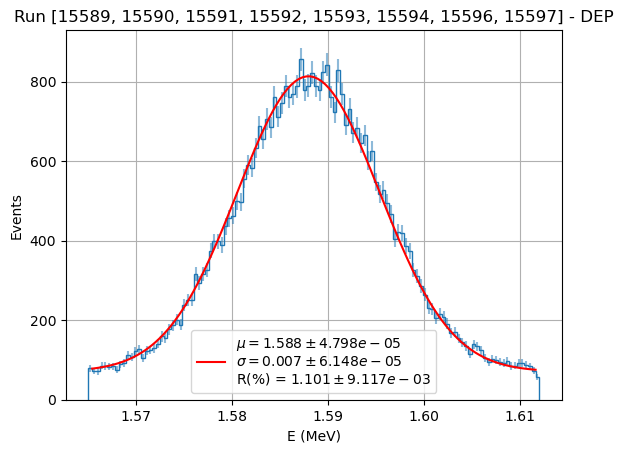

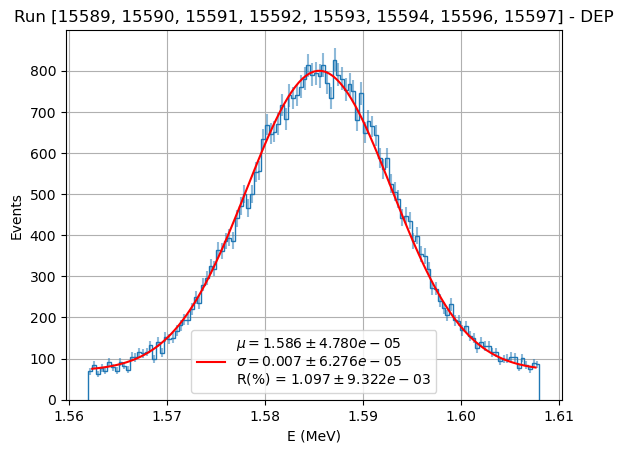

Energy resolution DEP: 1.177 ± 0.009 %
Energy resolution DEP (dZ corr): 1.177 ± 0.009 %
Energy resolution DEP (dZ + Z corr): 1.101 ± 0.009 %
Energy resolution DEP (dZ + Z + S1e corr): 1.097 ± 0.009 %


In [98]:
_, r_dep = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, dep_range, 120, title = 'Run {} - '.format(run_numbers) + 'DEP', plot = True)
plt.show()
_, r_dep_dZ = fit_whole_peaks(dp_correct[dp_correct.Rmax < 400], 'E_dZ', peak_fit, dep_range, 120, title = 'Run {} - '.format(run_numbers) + 'DEP', plot = True)
plt.show()
_, r_dep_dZ_Z = fit_whole_peaks(dp_correct[dp_correct.Rmax < 400], 'E_Z', peak_fit, (1.565, 1.612), 120, title = 'Run {} - '.format(run_numbers) + 'DEP', plot = True)
plt.show()
_, r_dep_dZ_Z_S1e = fit_whole_peaks(dp_correct[dp_correct.Rmax < 400], 'E_S1e', peak_fit, (1.562, 1.608), 120, title = 'Run {} - '.format(run_numbers) + 'DEP', plot = True)
plt.show()

print('Energy resolution DEP: {:.3f} ± {:.3f} %'.format(r_dep[0], r_dep[1]))
print('Energy resolution DEP (dZ corr): {:.3f} ± {:.3f} %'.format(r_dep_dZ[0], r_dep_dZ[1]))
print('Energy resolution DEP (dZ + Z corr): {:.3f} ± {:.3f} %'.format(r_dep_dZ_Z[0], r_dep_dZ_Z[1]))
print('Energy resolution DEP (dZ + Z + S1e corr): {:.3f} ± {:.3f} %'.format(r_dep_dZ_Z_S1e[0], r_dep_dZ_Z_S1e[1]))


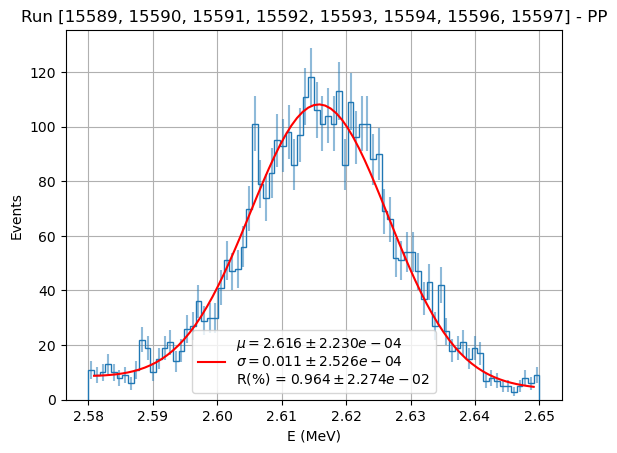

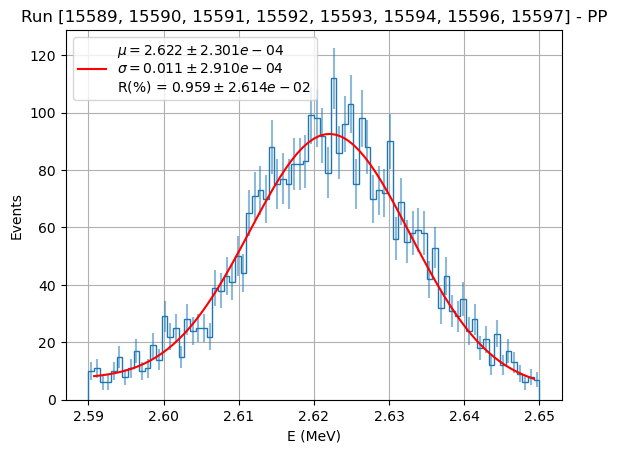

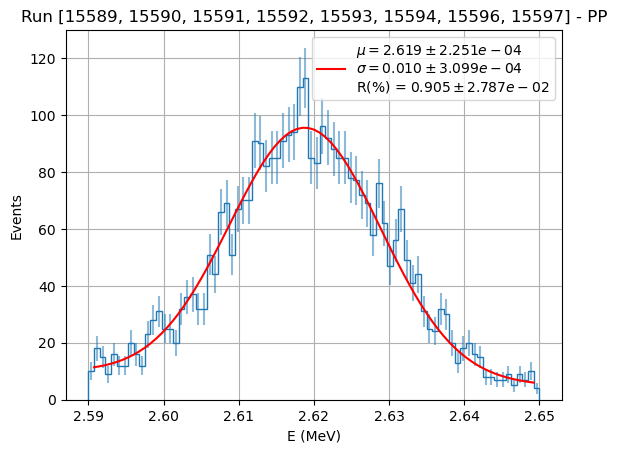

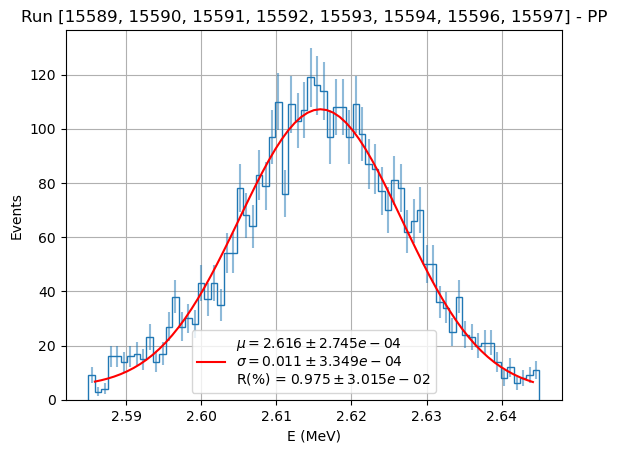

Energy resolution PP: 0.964 ± 0.023 %
Energy resolution PP (dZ corr): 0.959 ± 0.026 %
Energy resolution PP (dZ + Z corr): 0.905 ± 0.028 %
Energy resolution PP (dZ + Z + S1e corr): 0.975 ± 0.030 %


In [104]:
_, r_pp = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, pp_range, 80, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True)
plt.show()
_, r_pp_dZ = fit_whole_peaks(pp_correct[pp_correct.Rmax < 400], 'E_dZ', peak_fit, (2.59, 2.65), 80, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True)
plt.show()
_, r_pp_Z = fit_whole_peaks(pp_correct[pp_correct.Rmax < 400], 'E_Z', peak_fit, (2.59, 2.65), 80, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True)
plt.show()
_, r_pp_dZ_Z_S1e = fit_whole_peaks(pp_correct[pp_correct.Rmax < 400], 'E_S1e', peak_fit, (2.585, 2.645), 70, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True)
plt.show()

print('Energy resolution PP: {:.3f} ± {:.3f} %'.format(r_pp[0], r_pp[1]))
print('Energy resolution PP (dZ corr): {:.3f} ± {:.3f} %'.format(r_pp_dZ[0], r_pp_dZ[1]))
print('Energy resolution PP (dZ + Z corr): {:.3f} ± {:.3f} %'.format(r_pp_Z[0], r_pp_Z[1]))
print('Energy resolution PP (dZ + Z + S1e corr): {:.3f} ± {:.3f} %'.format(r_pp_dZ_Z_S1e[0], r_pp_dZ_Z_S1e[1]))

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Example data (replace with your real data)
df = reco_summ[in_range(reco_summ.E_shifted, 1.5, 1.7) & in_range(reco_summ.dZ, 0, 500)]

# Set Z bin edges
plot_var = 'E_shifted'
var = 'dZ'
num_bins = 20
z_bins = np.linspace(df[var].min(), df[var].max(), num_bins + 1)

# Create a slider for selecting Z bin index
z_bin_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(z_bins) - 2,
    step=1,
    description='Z bin:',
    continuous_update=True
)

# Output widget for plot
out = widgets.Output()

def update_plot(change):
    with out:
        clear_output(wait=True)
        
        # Get current Z bin range
        bin_idx = z_bin_slider.value
        z_min = z_bins[bin_idx]
        z_max = z_bins[bin_idx + 1]

        # Filter data for current Z bin
        mask = (df[var] >= z_min) & (df[var] < z_max)
        e_data = df.loc[mask, plot_var]

        # Compute histogram of E
        counts, edges = np.histogram(e_data, bins=100)

        # Plot
        plt.figure(figsize=(6, 4))
        plt.bar(edges[:-1], counts, width=np.diff(edges), edgecolor='black', align='edge')
        plt.title(f'Histogram of E for Z in [{z_min:.2f}, {z_max:.2f}]')
        plt.xlabel('E')
        plt.ylabel('Count')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Attach callback
z_bin_slider.observe(update_plot, names='value')

# Display
# display(z_bin_slider)
# update_plot(None)
# display(out)

update_plot(None) 
display(out, z_bin_slider)


Output()

IntSlider(value=0, description='Z bin:', max=19)

## Contar hits scatter

Necesito mirar cuántos hits estamos eliminando, cuanto contribuyen a la energía, etc, etc.. Para eso, hay que cambiar cositas digo yo

In [3]:
from sklearn.neighbors import NearestNeighbors

from   typing      import List
from   typing      import Callable

from invisible_cities.reco.corrections import read_maps, apply_all_correction
from invisible_cities.types.symbols import NormStrategy

In [4]:
def drop_isolated_clusters(distance: List[float] = [16., 16., 4.], nhit: int = 3,
                           variables: List[str] = []) -> Callable:
    '''
    If len(distance) == 2, it will perform on X, Y
    If len(distance) == 3, it will perform on X, Y, Z
    '''
    ndim = len(distance)
    dist = np.sqrt(ndim)

    def drop(df: pd.DataFrame) -> pd.DataFrame:
        if len(df) == 0:
            return df
        coords = []

        coords.append(df.X.values / distance[0])
        coords.append(df.Y.values / distance[1])

        if ndim == 3:
            coords.append(df.Z.values / distance[2])

        coords = np.column_stack(coords)

        try:
            nbrs = NearestNeighbors(radius=dist, algorithm='ball_tree').fit(coords)
            neighbors = nbrs.radius_neighbors(coords, return_distance=False)
            mask = np.array([len(neigh) > nhit for neigh in neighbors])
        except Exception as e:
            print(f"Error in NearestNeighbors: {{e}}")
            return df.iloc[:0]  # fallback: return empty

        pass_df = df.loc[mask].copy()

        if not pass_df.empty and variables:
            with np.errstate(divide='ignore', invalid='ignore'):
                columns = pass_df.loc[:, variables]
                scale = df[variables].sum().values / columns.sum().values
                columns *= scale
                pass_df.loc[:, variables] = columns

        return pass_df
    return drop



In [5]:
map_path = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/new_HE_runs/rough_geometry_map_v2.h5' 
# Energy correction
maps = read_maps(map_path)

corr_fun  = apply_all_correction(maps
                                 , apply_temp = False
                                 , norm_strat = NormStrategy.kr)
# Cluster dropping
dist = [16., 16., 4.]
dropper = drop_isolated_clusters(distance = dist, nhit = 3, variables = ['Ec'])

In [6]:
def correct_and_drop(df, corr_fun, dropper):
    factor = corr_fun(df.X, df.Y, df.Z, df.time)
    df['Ec'] = df.E * factor
    #correct energy in the borders (for NaN hits)
    factor_border = corr_fun([479],[0],[0],[1])
    df["Ec_border"] = df.E * factor_border
    # add the latter energy
    df["Ec"] = df["Ec"].fillna(df["Ec_border"])

    #surviving hits after applying dropper function (they have the energy changed)
    df_surv = df.groupby(['event', 'npeak'], group_keys=False).apply(dropper)

    # dropped hits after the dropper (but with original energy)
    df_dropped = df.reset_index(drop=True).merge(df_surv.drop(columns = 'Ec').reset_index(drop=True), how='outer', indicator=True).query('_merge == "left_only"').drop(columns='_merge')
    # non dropped hits after the dropper (but with original energy)
    df_nondrop = df.reset_index(drop=True).merge(df_surv.drop(columns = 'Ec').reset_index(drop=True), how='outer', indicator=True).query('_merge == "both"').drop(columns='_merge')
    return df_surv, df_dropped, df_nondrop

In [7]:
run_number = 15589
data_path = '/mnt/netapp1/Store_next_data/NEXT100/data/{run_number}'.format(run_number = run_number) + '/*/*/*/*/*/*/'
files = sorted(glob.glob(data_path + '/*/*'), key=lambda x: (x.split('/')[-2], int(x.split('/')[-1].split('_')[2])))

file_name = '/{ldc_n}/run_{run_n}_{file_n}_{ldc_n}_*.h5'

wf_sel = pd.read_hdf(path.format(run_folder = run_folder, run_number = run_number) + wf_selection_name.format(run_number), 'RUN/Selected_events')

In [8]:
# savepath = path.format(run_folder = run_folder, run_number = run_number) + 'DEP_events_run_{rn}.txt'.format(rn = run_number)

# dep_ev_numbers = sorted(wf_sel[(wf_sel.total_energy > 1) & (wf_sel.total_energy < 2)].event.values)
# with open(savepath, "w") as file:
#     for number in dep_ev_numbers:
#         file.write(f"{number}\n")

In [10]:
coord = 'Z'
separations = {'X':16, 'Y':16, 'Z':4}

In [52]:
def get_boundary_hits(nondrop, drop, coord):
    min_, max_ = nondrop[coord].min(), nondrop[coord].max()
    in_range_mask = in_range(drop[coord], (min_, max_))
    in_hits = drop[in_range_mask]
    out_hits = drop[~in_range_mask]
    return in_hits, out_hits, in_range_mask

655 ldc4


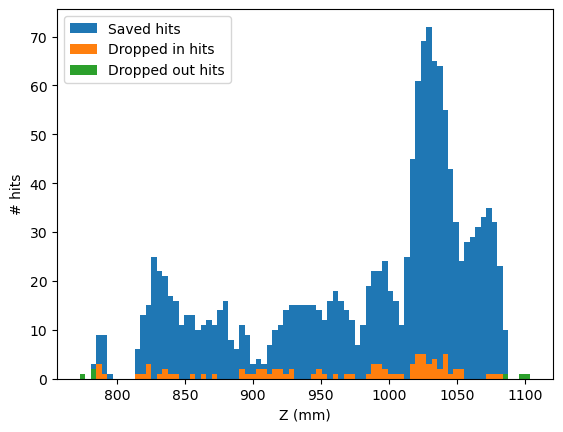

1.6075103036203509
970 ldc4


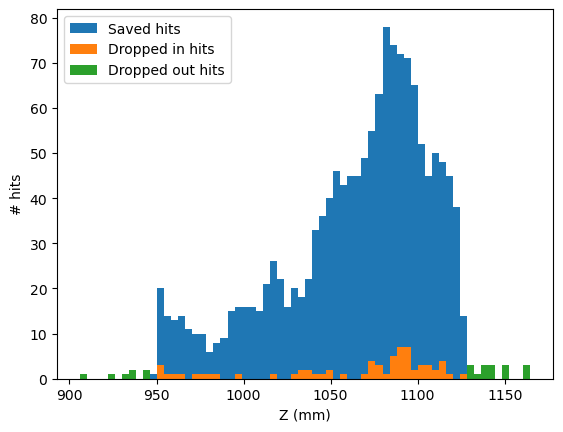

1.6846171946126343
1047 ldc4


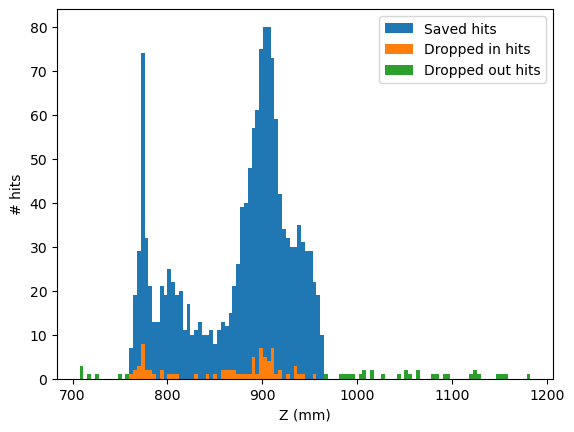

1.7004289070925898
3819 ldc4


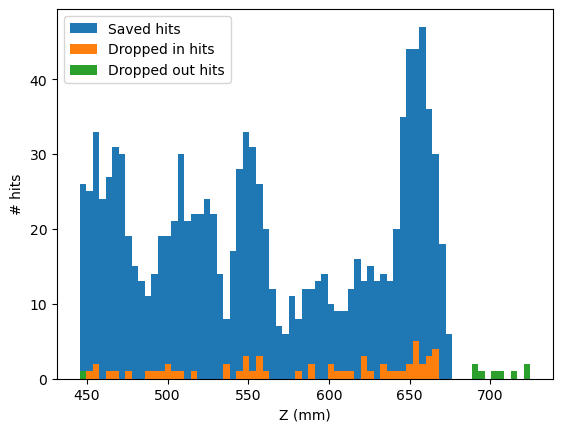

1.6247775850382915
4862 ldc4


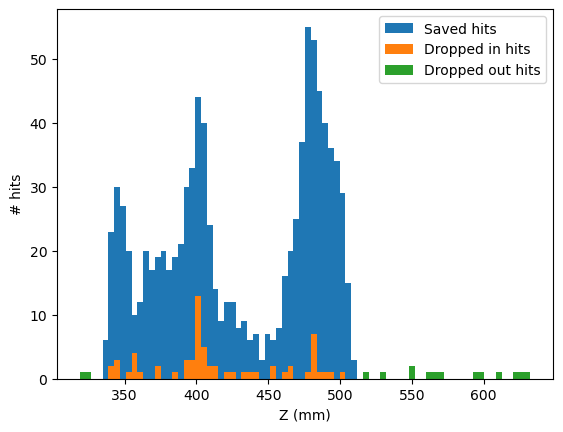

1.6250102841194083
7704 ldc4


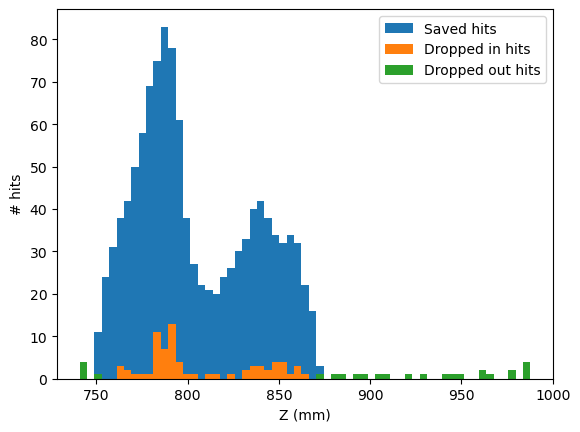

1.6726807024691157
10084 ldc4


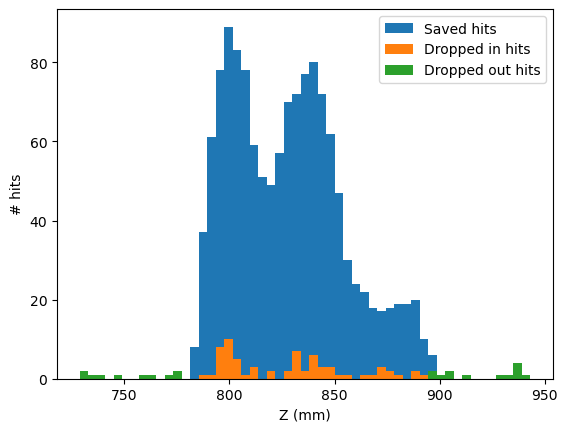

1.6795186672738827
12485 ldc4


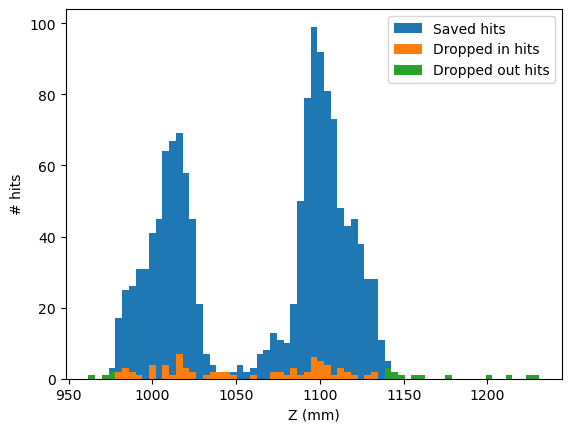

1.691489129240495
13577 ldc4


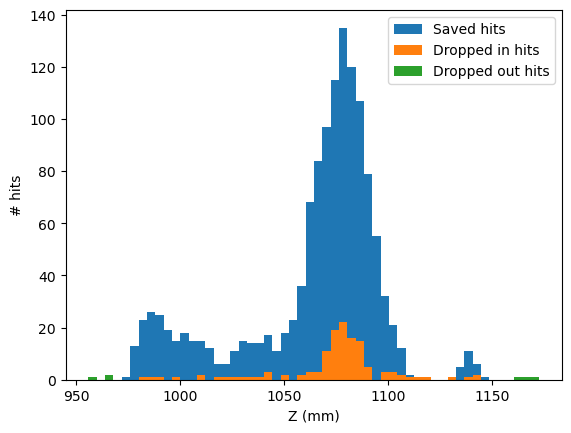

1.7598522420646834
13717 ldc4


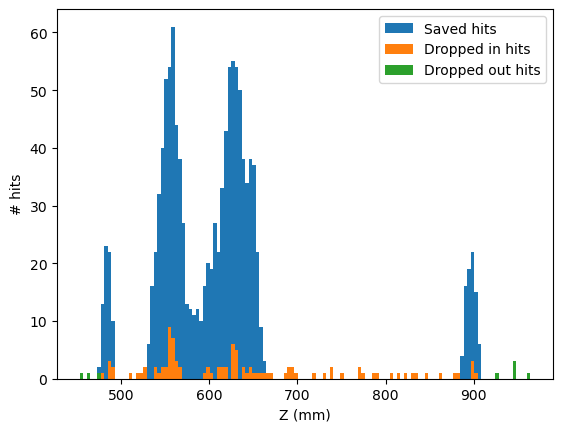

1.6701548359292047
13780 ldc4


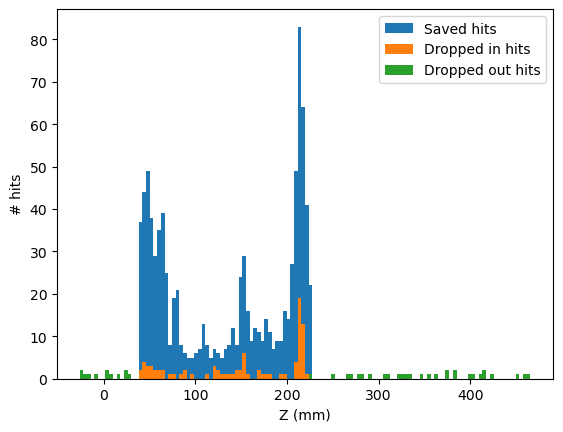

1.6748644801117551


In [70]:
for i, row in wf_sel[(wf_sel.total_energy > 1) & (wf_sel.total_energy < 2)].reset_index(drop=True).iterrows(): #.sort_values(['ldc_n', 'file_n'])
    print(row.event, row.ldc_n)
    f = glob.glob(data_path.format(run_number = run_number) + file_name.format(ldc_n = row.ldc_n, run_n = run_number, file_n = row.file_n))
    df = pd.read_hdf(f[0], 'RECO/Events')
    ev = df[df.event == row.event].copy()

    ev_final, ev_dropped, ev_nondrop = correct_and_drop(ev, corr_fun, dropper)

    # Boundaries of the whole event to PLOT the histogram (nothing to do with the decided hits)
    cmin, cmax = ev[coord].min(), ev[coord].max()
    cwidth = ev[coord].sort_values().drop_duplicates().diff().min()
    nbins = int((cmax - cmin) / separations[coord])

    # Boundaries of the non dropped, to get the outside hits
    drop_in_Z, drop_out_Z, range_Z = get_boundary_hits(ev_nondrop, ev_dropped, 'Z')

    plt.hist(ev_nondrop[coord], nbins, (cmin, cmax), label = 'Saved hits')
    # plt.hist(ev_dropped[coord], nbins, (cmin, cmax), label = 'Dropped hits')
    plt.hist(drop_in_Z[coord], nbins, (cmin, cmax), label = 'Dropped in hits')
    plt.hist(drop_out_Z[coord], nbins, (cmin, cmax), label = 'Dropped out hits')
    plt.xlabel(f'{coord} (mm)')
    plt.ylabel('# hits')
    plt.legend()
    plt.show()
    print(ev.Ec.sum())
    
    if i == 10:
        break

No handles with labels found to put in legend.


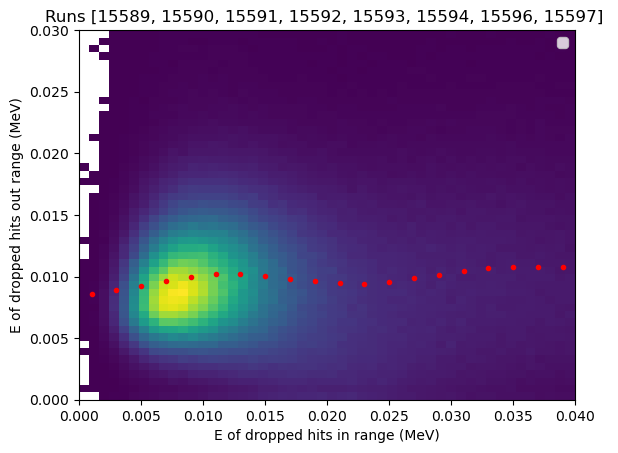

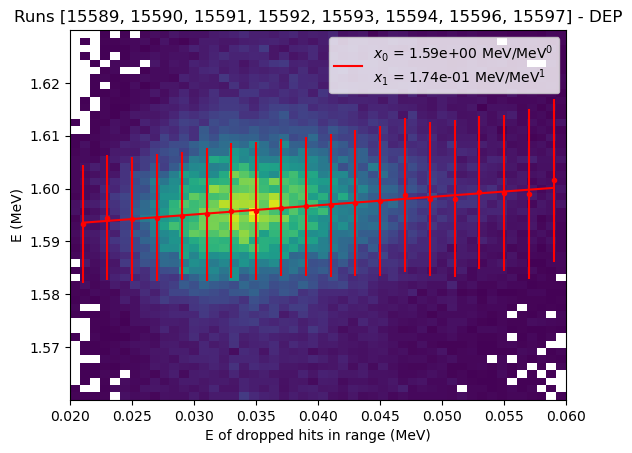

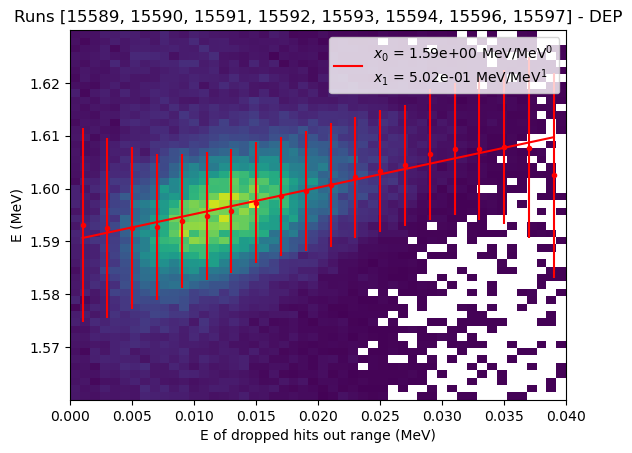

array([0.50224221, 1.59013817])

In [75]:
plot_profile(reco_summ, 'Ec_drop_in', 'Ec_drop_out', fitfun=None, initial_values=(1.67, 0), std = False, fitbins=20, plotbins=(50, 50), fitrange=((0, 0.04), (0, 0.03)), plotrange=((0, 0.04), (0, 0.03)), axlabel = ['E of dropped hits in range', 'E of dropped hits out range'], units = ['MeV', 'MeV'], title='Runs {} '.format(run_numbers), cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'Ec_drop_in', 'E_shifted', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=20, plotbins=(50, 50), fitrange=((0.02, 0.06), None), plotrange=((0.02, 0.06), None), axlabel = ['E of dropped hits in range', 'E'], units = ['MeV', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'Ec_drop_out', 'E_shifted', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=20, plotbins=(50, 50), fitrange=((0, 0.04), None), plotrange=((0, 0.04), None), axlabel = ['E of dropped hits out range', 'E'], units = ['MeV', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
